In [1]:
!nvidia-smi

Sat Aug 22 19:35:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DATA_DIR = Path("/kaggle/input/competitions/soil-grain-size-from-photos")
TRAIN_CSV = DATA_DIR / "Training_labels_updated.csv"
PPM_CSV = DATA_DIR / "ppm_updated.csv"
SAMPLE_SUBMISSION_CSV = DATA_DIR / "sample_submission.csv"
TRAIN_IMAGE_DIR = DATA_DIR / "Training-All_Photos_updated/Training-All_Photos_updated"
TEST_IMAGE_DIR = DATA_DIR / "Test_All_Photos/Test_All_Photos"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}

train = pd.read_csv(TRAIN_CSV)
ppm = pd.read_csv(PPM_CSV)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_CSV)
train["sample_id"] = train["sample_id"].astype(str)
sample_submission["sample_id"] = sample_submission["sample_id"].astype(str)

GRAIN_COLS = [c for c in train.columns if c != "sample_id"]
GRAIN_SIZES = np.array(GRAIN_COLS, dtype=float)
train_images = sorted(p for p in TRAIN_IMAGE_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
test_images = sorted(p for p in TEST_IMAGE_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 180)

print(f"Labels: {train.shape} | PPM: {ppm.shape} | Submission: {sample_submission.shape}")
print(f"Training images: {len(train_images)} | Test images: {len(test_images)}")
print(f"Grain sizes: {GRAIN_SIZES.tolist()}")

Labels: (24, 12) | PPM: (5, 5) | Submission: (10, 12)
Training images: 127 | Test images: 35
Grain sizes: [0.002, 0.0063, 0.02, 0.063, 0.2, 0.63, 2.0, 6.3, 20.0, 63.0, 200.0]


# 1. Data Analysis

In [3]:
train_ids = train["sample_id"].tolist()
test_ids = sample_submission["sample_id"].tolist()

def index_images(paths, sample_ids):
    rows = []
    for path in paths:
        matches = [sid for sid in sample_ids if sid.casefold() in path.name.casefold()]
        rows.append({"filename": path.name, "path": str(path), "sample_id": matches[0] if len(matches) == 1 else None, "id_matches": len(matches)})
    return pd.DataFrame(rows)

train_image_index = index_images(train_images, train_ids)
test_image_index = index_images(test_images, test_ids)

train_mapping = train_image_index.groupby("sample_id").agg(images=("filename", "size"), example_file=("filename", "first")).reindex(train_ids).rename_axis("sample_id").reset_index()
test_mapping = test_image_index.groupby("sample_id").agg(images=("filename", "size"), example_file=("filename", "first")).reindex(test_ids).rename_axis("sample_id").reset_index()

print("Training label preview")
display(train.head())
print("Camera/PPM metadata")
display(ppm)

print(f"Training IDs ({len(train_ids)}): {train_ids}")
print(f"Test IDs ({len(test_ids)}): {test_ids}")

print("\nFilename examples")
display(pd.DataFrame({"training": pd.Series([p.name for p in train_images[:12]]), "test": pd.Series([p.name for p in test_images[:12]])}))

print("\nTraining image mapping")
display(train_mapping)
print("Test image mapping")
display(test_mapping)

bad_mapping = pd.concat([train_image_index.assign(split="train"), test_image_index.assign(split="test")], ignore_index=True)
bad_mapping = bad_mapping[bad_mapping["id_matches"] != 1]
print(f"Images without exactly one sample-ID match: {len(bad_mapping)}")
if len(bad_mapping): display(bad_mapping[["split", "filename", "id_matches"]].head(30))

Training label preview


,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,F827,9.4904,19.3892,47.6257,89.5554,99.8965,99.9896,100.0000,100.0000,100.0000,100.0000,100.0
1,G190,5.2076,10.2425,23.7537,50.3113,75.8311,85.7233,90.9898,94.8969,98.5814,100.0000,100.0
2,H030,6.7833,10.9091,19.0599,37.3235,66.8349,96.4965,97.9530,99.5691,100.0000,100.0000,100.0
3,H037,0.9320,6.4500,16.3216,27.8019,34.6629,46.3652,62.7168,79.0523,89.7830,100.0000,100.0
4,H038,1.8218,5.1400,10.6113,18.2778,24.6420,35.0767,47.2345,63.3992,81.0851,95.7127,100.0


Camera/PPM metadata


,phone,camera,width,height,ppm
0,iPhone 14,iPhone 14,4032,3024,13.942
1,iPhone 16,iPhone 16,5712,4284,19.525
2,Motorola Edge,motorola edge 20,4000,1800,11.492
3,Motorola Edge 60 Fusion,Motorola Edge 60 fusion,4096,2304,12.465
4,Samsung A52,SM-A525F,9248,6936,26.330


Training IDs (24): ['F827', 'G190', 'H030', 'H037', 'H038', 'H126', 'H181', 'H183', 'H366', 'H367', 'H368', 'H371', 'H372', 'H374', 'H405', 'H493', 'H516', 'H549', 'H615', 'H616', 'H617', 'H637', 'H666', 'H668']
Test IDs (10): ['HPC_Airbus BS6-3', 'HPC_Audorfring', 'HPC_Muenster_BS6_9_0-10m', 'HPC_Airbus BS10-4bis7', 'HPC_Airbus BS12-5bis8', 'HPC_Kleinkummerfeld 2-2', 'HPC_Kleinkummerfeld 2-3', 'HPC_Kleinkummerfeld 9-4', 'HPC_Kleinkummerfeld 18-3', 'HPC_Testfeld Lidl WHV']

Filename examples


...

,sample_id,images,example_file
0,F827,5,Motorola_Edge_F827_01.jpg
1,G190,5,Motorola_Edge_G190_01.jpg
2,H030,7,Motorola_Edge_H030_01.jpg
3,H037,6,Motorola_Edge_H037_01.jpg
4,H038,8,Motorola_Edge_H038_01.jpg
5,H126,4,Motorola_Edge_H126_01.jpg
6,H181,6,Motorola_Edge_H181_01.jpg
7,H183,7,Motorola_Edge_H183_01.jpg
8,H366,4,Motorola_Edge_H366_01.jpg
9,H367,4,Motorola_Edge_H367_01.jpg


Test image mapping


,sample_id,images,example_file
0,HPC_Airbus BS6-3,3.0,iPhone16_HPC_Airbus BS6-3 (2).JPG
1,HPC_Audorfring,5.0,iPhone14_HPC_Audorfring (1).JPG
2,HPC_Muenster_BS6_9_0-10m,NaN,NaN
3,HPC_Airbus BS10-4bis7,3.0,iPhone16_HPC_Airbus BS10-4bis7 (2).JPG
4,HPC_Airbus BS12-5bis8,3.0,iPhone16_HPC_Airbus BS12-5bis8 (2).JPG
5,HPC_Kleinkummerfeld 2-2,3.0,iPhone16_HPC_Kleinkummerfeld 2-2 (2).JPG
6,HPC_Kleinkummerfeld 2-3,3.0,iPhone16_HPC_Kleinkummerfeld 2-3 (1).JPG
7,HPC_Kleinkummerfeld 9-4,3.0,iPhone16_HPC_Kleinkummerfeld 9-4 (2).JPG
8,HPC_Kleinkummerfeld 18-3,3.0,iPhone16_HPC_Kleinkummerfeld 18-3 (1).JPG
9,HPC_Testfeld Lidl WHV,4.0,iPhone14_HPC_Testfeld Lidl WHV (1).JPG


Images without exactly one sample-ID match: 5


,split,filename,id_matches
132,test,"iPhone14_HPC_Münster_BS6_9,0-10m (1).JPG",0
133,test,"iPhone14_HPC_Münster_BS6_9,0-10m (2).JPG",0
134,test,"iPhone14_HPC_Münster_BS6_9,0-10m (3).JPG",0
135,test,"iPhone14_HPC_Münster_BS6_9,0-10m (4).JPG",0
136,test,"iPhone14_HPC_Münster_BS6_9,0-10m (5).JPG",0


In [4]:
import re, unicodedata
from PIL import Image

GERMAN_CHARS = str.maketrans({"ä": "ae", "ö": "oe", "ü": "ue", "ß": "ss", "Ä": "Ae", "Ö": "Oe", "Ü": "Ue"})
PHONE_PREFIXES = [("motorolaedge60fusion", "Motorola Edge 60 Fusion"), ("motorolaedge", "Motorola Edge"),
                  ("samsunga52", "Samsung A52"), ("iphone14", "iPhone 14"), ("iphone16", "iPhone 16")]

def normalize_text(value):
    value = unicodedata.normalize("NFKD", str(value).translate(GERMAN_CHARS)).encode("ascii", "ignore").decode().casefold()
    return re.sub(r"[^a-z0-9]+", "", value)

def build_image_index(paths, sample_ids, split):
    id_keys, rows = {sid: normalize_text(sid) for sid in sample_ids}, []
    for path in tqdm(paths, desc=f"Reading {split} image metadata"):
        key = normalize_text(path.stem)
        matches = [sid for sid, id_key in id_keys.items() if id_key in key]
        phone = next((phone for prefix, phone in PHONE_PREFIXES if key.startswith(prefix)), None)
        with Image.open(path) as im:
            rows.append({"split": split, "sample_id": matches[0] if len(matches) == 1 else None, "id_matches": len(matches),
                         "phone": phone, "filename": path.name, "path": str(path), "image_width": im.width,
                         "image_height": im.height, "format": im.format, "frames": getattr(im, "n_frames", 1)})
    return pd.DataFrame(rows)

train_image_index = build_image_index(train_images, train_ids, "train")
test_image_index = build_image_index(test_images, test_ids, "test")
all_images = pd.concat([train_image_index, test_image_index], ignore_index=True)

camera_meta = ppm.rename(columns={"width": "reference_width", "height": "reference_height"})
all_images = all_images.merge(camera_meta, on="phone", how="left")
all_images["resize_scale"] = all_images[["image_width", "image_height"]].max(axis=1) / all_images[["reference_width", "reference_height"]].max(axis=1)
all_images["estimated_ppm"] = all_images["ppm"] * all_images["resize_scale"]

camera_summary = all_images.groupby(["split", "phone", "image_width", "image_height", "format", "frames"], dropna=False, as_index=False).agg(
    samples=("sample_id", "nunique"), images=("path", "size"), reference_ppm=("ppm", "first"),
    resize_scale=("resize_scale", "first"), estimated_ppm=("estimated_ppm", "first"))
test_coverage = all_images[all_images["split"].eq("test")].groupby("sample_id", as_index=False).agg(
    images=("path", "size"), phone=("phone", "first"), example_file=("filename", "first"))
mapping_problems = all_images[all_images["sample_id"].isna() | all_images["phone"].isna() | all_images["ppm"].isna()]

print("Camera and resolution summary")
display(camera_summary.round(3))
print("Corrected test mapping")
display(test_coverage)
print(f"Mapping or camera problems: {len(mapping_problems)}")
if len(mapping_problems): display(mapping_problems[["split", "filename", "sample_id", "phone", "id_matches"]])

Reading train image metadata:   0%|          | 0/127 [00:00<?, ?it/s]

Reading test image metadata:   0%|          | 0/35 [00:00<?, ?it/s]

Camera and resolution summary


,split,phone,image_width,image_height,format,frames,samples,images,reference_ppm,resize_scale,estimated_ppm
0,test,iPhone 14,4032,3024,MPO,2,3,14,13.942,1.000,13.942
1,test,iPhone 16,5712,4284,MPO,2,7,21,19.525,1.000,19.525
2,train,Motorola Edge,720,1600,JPEG,1,18,25,11.492,0.400,4.597
3,train,Motorola Edge,1600,720,JPEG,1,20,44,11.492,0.400,4.597
4,train,Motorola Edge 60 Fusion,4096,2304,JPEG,1,1,3,12.465,1.000,12.465
5,train,Samsung A52,1599,1200,JPEG,1,22,55,26.330,0.173,4.553


Corrected test mapping


,sample_id,images,phone,example_file
0,HPC_Airbus BS10-4bis7,3,iPhone 16,iPhone16_HPC_Airbus BS10-4bis7 (2).JPG
1,HPC_Airbus BS12-5bis8,3,iPhone 16,iPhone16_HPC_Airbus BS12-5bis8 (2).JPG
2,HPC_Airbus BS6-3,3,iPhone 16,iPhone16_HPC_Airbus BS6-3 (2).JPG
3,HPC_Audorfring,5,iPhone 14,iPhone14_HPC_Audorfring (1).JPG
4,HPC_Kleinkummerfeld 18-3,3,iPhone 16,iPhone16_HPC_Kleinkummerfeld 18-3 (1).JPG
5,HPC_Kleinkummerfeld 2-2,3,iPhone 16,iPhone16_HPC_Kleinkummerfeld 2-2 (2).JPG
6,HPC_Kleinkummerfeld 2-3,3,iPhone 16,iPhone16_HPC_Kleinkummerfeld 2-3 (1).JPG
7,HPC_Kleinkummerfeld 9-4,3,iPhone 16,iPhone16_HPC_Kleinkummerfeld 9-4 (2).JPG
8,HPC_Muenster_BS6_9_0-10m,5,iPhone 14,"iPhone14_HPC_Münster_BS6_9,0-10m (1).JPG"
9,HPC_Testfeld Lidl WHV,4,iPhone 14,iPhone14_HPC_Testfeld Lidl WHV (1).JPG


Mapping or camera problems: 0


Target quality


,count
missing target values,0
"samples outside [0, 100]",0
non-monotonic samples,0
samples not ending at 100,0
duplicate target curves,0


Cumulative target summary


,count,mean,std,min,25%,50%,75%,max
diameter_mm,,,,,,,,
0.002,24.0,3.05,4.11,0.00,0.76,1.18,4.96,17.71
0.0063,24.0,6.24,6.96,0.00,1.71,3.36,10.41,26.46
0.02,24.0,14.52,15.25,0.00,3.80,8.27,20.23,47.63
0.063,24.0,30.23,28.44,0.82,6.90,16.55,50.72,89.56
0.2,24.0,45.75,36.83,7.63,11.90,29.78,86.27,99.90
0.63,24.0,55.86,38.18,12.35,18.23,40.88,96.08,99.99
2,24.0,64.75,31.88,22.76,32.68,57.83,98.05,100.00
6.3,24.0,79.42,20.35,50.68,57.96,86.49,99.50,100.00
20,24.0,93.39,7.62,76.49,86.93,97.21,100.00,100.00


Non-cumulative mass distribution summary


,mean,std,min,median,max
grain_bin_mm,,,,,
<0.002,3.05,4.11,0.00,1.18,17.71
0.002–0.0063,3.19,3.22,0.00,1.57,9.90
0.0063–0.02,8.28,8.67,0.00,4.41,28.24
0.02–0.063,15.71,14.51,0.82,8.07,41.93
0.063–0.2,15.52,14.83,2.94,8.47,45.46
0.2–0.63,10.11,10.41,0.09,6.85,49.84
0.63–2,8.89,7.94,0.01,10.75,31.39
2–6.3,14.67,13.60,0.00,15.60,40.98
6.3–20,13.97,14.05,0.00,8.41,36.74


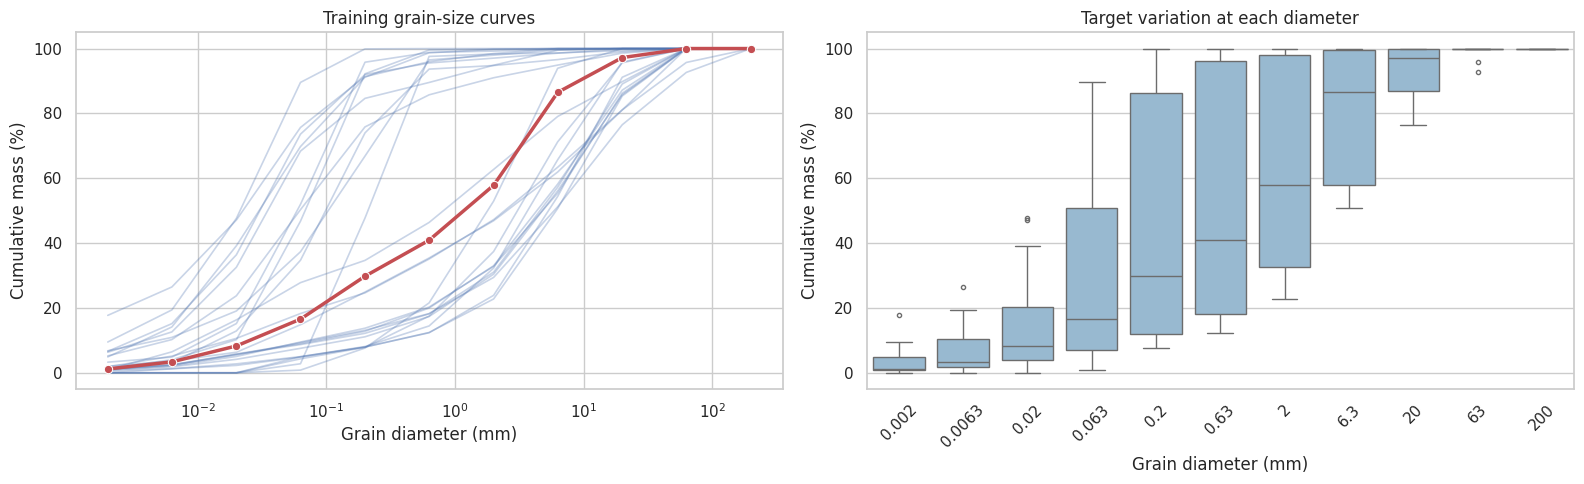

In [5]:
targets = train[GRAIN_COLS].to_numpy(float)
increments = np.diff(np.column_stack([np.zeros(len(train)), targets]), axis=1)
bin_labels = [f"<{GRAIN_COLS[0]}"] + [f"{left}–{right}" for left, right in zip(GRAIN_COLS[:-1], GRAIN_COLS[1:])]

quality = pd.Series({
    "missing target values": np.isnan(targets).sum(),
    "samples outside [0, 100]": (((targets < 0) | (targets > 100)).any(axis=1)).sum(),
    "non-monotonic samples": (np.diff(targets, axis=1) < -1e-8).any(axis=1).sum(),
    "samples not ending at 100": (~np.isclose(targets[:, -1], 100)).sum(),
    "duplicate target curves": pd.DataFrame(targets).duplicated().sum()
}, name="count")

target_summary = train[GRAIN_COLS].describe().T
target_summary.index.name = "diameter_mm"
bin_summary = pd.DataFrame(increments, columns=bin_labels).agg(["mean", "std", "min", "median", "max"]).T
bin_summary.index.name = "grain_bin_mm"

print("Target quality")
display(quality.to_frame())
print("Cumulative target summary")
display(target_summary.round(2))
print("Non-cumulative mass distribution summary")
display(bin_summary.round(2))

target_long = train.melt(id_vars="sample_id", value_vars=GRAIN_COLS, var_name="diameter", value_name="cumulative_pct")
target_long["diameter_mm"] = target_long["diameter"].astype(float)
median_curve = train[GRAIN_COLS].median().rename_axis("diameter").reset_index(name="cumulative_pct")
median_curve["diameter_mm"] = median_curve["diameter"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=target_long, x="diameter_mm", y="cumulative_pct", units="sample_id", estimator=None,
             color="#4C72B0", alpha=.3, linewidth=1.2, legend=False, ax=axes[0])
sns.lineplot(data=median_curve, x="diameter_mm", y="cumulative_pct", color="#C44E52", marker="o", linewidth=2.5, ax=axes[0])
axes[0].set(xscale="log", xlabel="Grain diameter (mm)", ylabel="Cumulative mass (%)", title="Training grain-size curves")
sns.boxplot(data=target_long, x="diameter", y="cumulative_pct", order=GRAIN_COLS, color="#8FBBD9", fliersize=3, ax=axes[1])
axes[1].set(xlabel="Grain diameter (mm)", ylabel="Cumulative mass (%)", title="Target variation at each diameter")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [6]:
all_images["long_side_mm"] = all_images[["image_width", "image_height"]].max(axis=1) / all_images["estimated_ppm"]
all_images["short_side_mm"] = all_images[["image_width", "image_height"]].min(axis=1) / all_images["estimated_ppm"]

physical_summary = all_images.groupby(["split", "phone", "image_width", "image_height"], as_index=False).agg(
    samples=("sample_id", "nunique"), images=("path", "size"), estimated_ppm=("estimated_ppm", "first"),
    long_side_mm=("long_side_mm", "first"), short_side_mm=("short_side_mm", "first"))

train_camera_coverage = all_images[all_images["split"].eq("train")].pivot_table(
    index="sample_id", columns="phone", values="path", aggfunc="count", fill_value=0).reindex(train_ids).fillna(0).astype(int)
camera_columns = train_camera_coverage.columns.tolist()
train_camera_coverage["cameras"] = (train_camera_coverage[camera_columns] > 0).sum(axis=1)
train_camera_coverage["total_images"] = train_camera_coverage[camera_columns].sum(axis=1)

print("Resolution, estimated scale, and physical field of view")
display(physical_summary.round(2))
print("Training camera coverage by sample")
display(train_camera_coverage)
print("Number of cameras available per training sample")
display(train_camera_coverage["cameras"].value_counts().sort_index().rename_axis("cameras").to_frame("samples"))

Resolution, estimated scale, and physical field of view


,split,phone,image_width,image_height,samples,images,estimated_ppm,long_side_mm,short_side_mm
0,test,iPhone 14,4032,3024,3,14,13.94,289.20,216.90
1,test,iPhone 16,5712,4284,7,21,19.52,292.55,219.41
2,train,Motorola Edge,720,1600,18,25,4.60,348.07,156.63
3,train,Motorola Edge,1600,720,20,44,4.60,348.07,156.63
4,train,Motorola Edge 60 Fusion,4096,2304,1,3,12.46,328.60,184.84
5,train,Samsung A52,1599,1200,22,55,4.55,351.23,263.59


Training camera coverage by sample


phone,Motorola Edge,Motorola Edge 60 Fusion,Samsung A52,cameras,total_images
sample_id,,,,,
F827,2,0,3,2,5
G190,2,0,3,2,5
H030,4,0,3,2,7
H037,3,0,3,2,6
H038,3,0,5,2,8
H126,3,0,1,2,4
H181,4,0,2,2,6
H183,4,0,3,2,7
H366,4,0,0,1,4


Number of cameras available per training sample


,samples
cameras,
1,3
2,21


Representative training photographs:   0%|          | 0/24 [00:00<?, ?it/s]

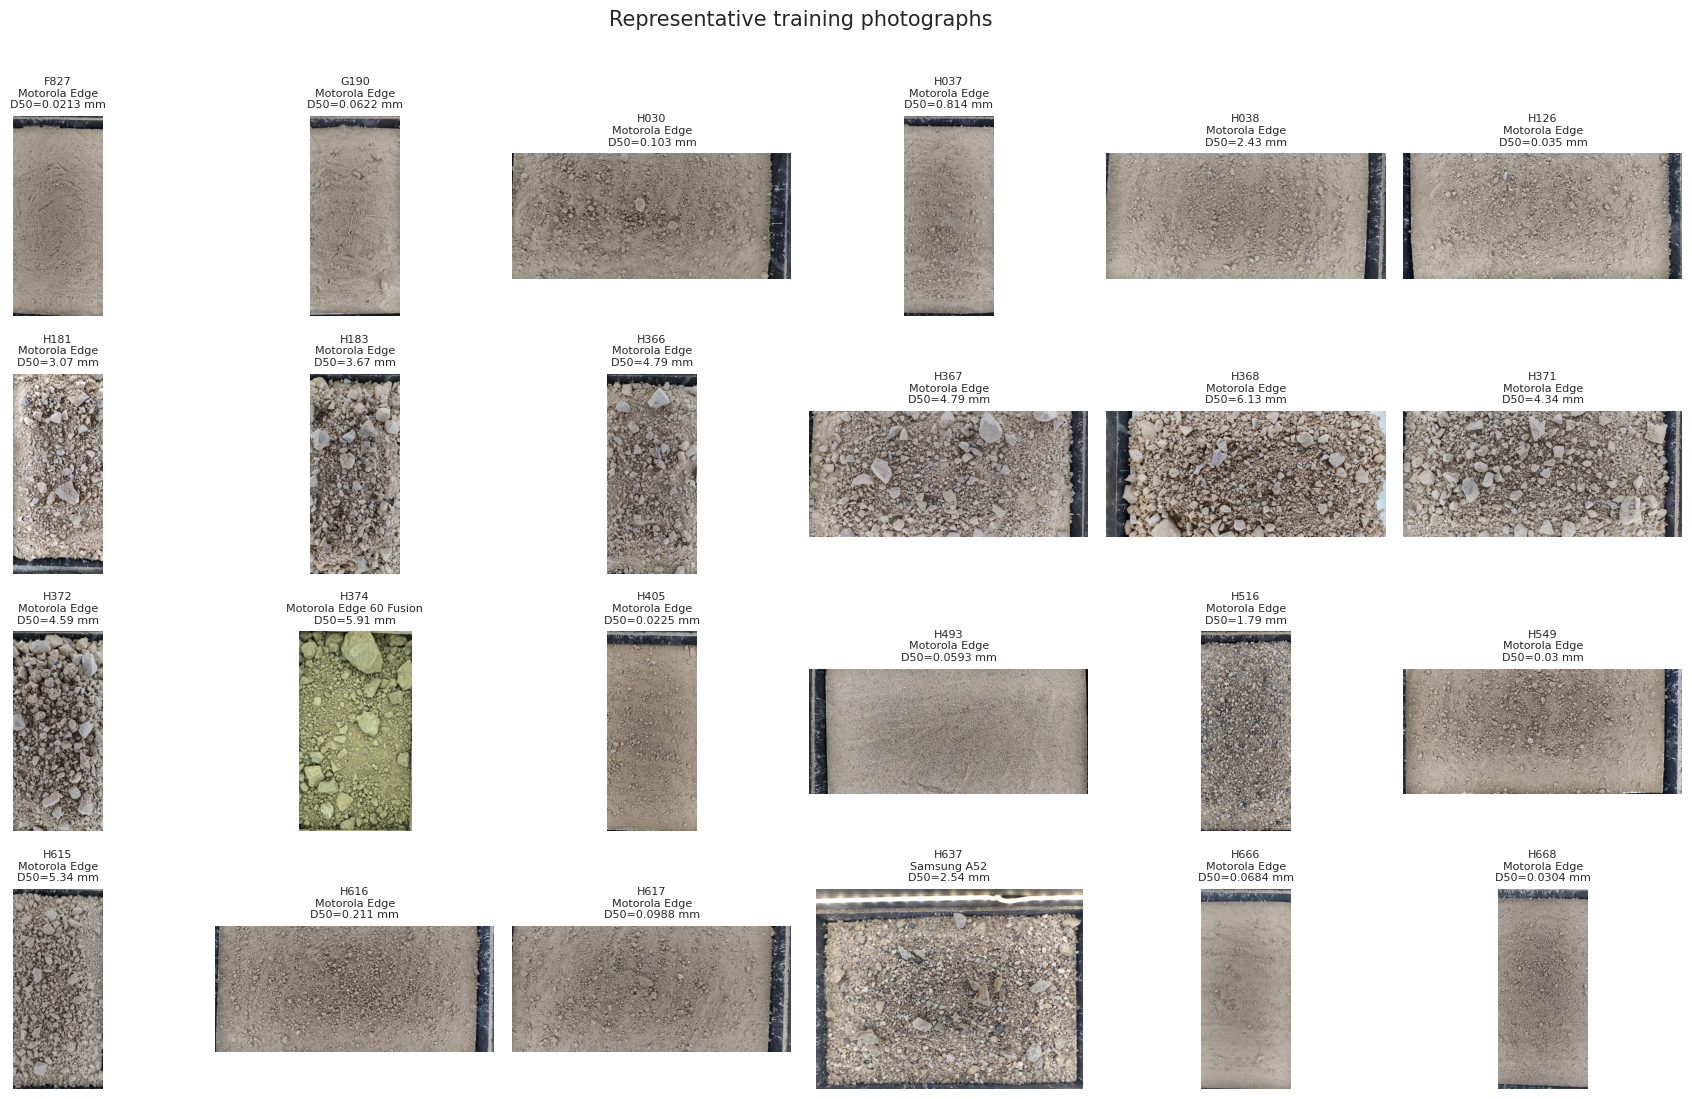

Representative test photographs:   0%|          | 0/10 [00:00<?, ?it/s]

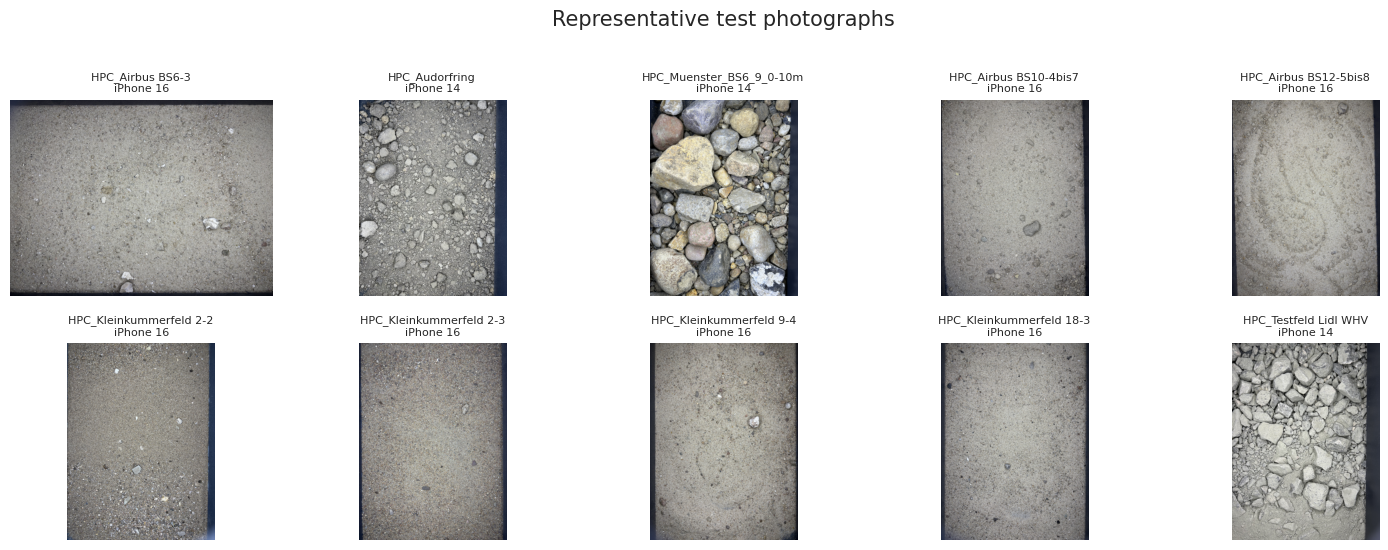

In [7]:
from PIL import ImageOps

def diameter_at_percent(cdf, percent=50):
    index = np.searchsorted(cdf, percent)
    if index == 0: return GRAIN_SIZES[0]
    if index >= len(cdf): return GRAIN_SIZES[-1]
    y0, y1 = cdf[index - 1], cdf[index]
    if np.isclose(y0, y1): return GRAIN_SIZES[index]
    fraction = (percent - y0) / (y1 - y0)
    return 10 ** (np.log10(GRAIN_SIZES[index - 1]) + fraction * np.log10(GRAIN_SIZES[index] / GRAIN_SIZES[index - 1]))

d50_by_sample = {sid: diameter_at_percent(cdf) for sid, cdf in zip(train_ids, targets)}

def show_sample_grid(frame, sample_ids, title, ncols=6):
    examples = frame.drop_duplicates("sample_id").set_index("sample_id").reindex(sample_ids).dropna(subset=["path"]).reset_index()
    nrows = int(np.ceil(len(examples) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.8))
    axes = np.atleast_1d(axes).ravel()
    for ax, row in zip(axes, tqdm(examples.itertuples(index=False), total=len(examples), desc=title)):
        with Image.open(row.path) as im:
            im.seek(0)
            image = ImageOps.exif_transpose(im).convert("RGB")
            image.thumbnail((600, 450))
        d50 = f"\nD50={d50_by_sample[row.sample_id]:.3g} mm" if row.sample_id in d50_by_sample else ""
        ax.imshow(image)
        ax.set_title(f"{row.sample_id}\n{row.phone}{d50}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(examples):]: ax.axis("off")
    fig.suptitle(title, fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, .97])
    plt.show()

show_sample_grid(all_images[all_images["split"].eq("train")], train_ids, "Representative training photographs")
show_sample_grid(all_images[all_images["split"].eq("test")], test_ids, "Representative test photographs", ncols=5)

,phone,filename,frame,width,height,mode
0,iPhone 14,iPhone14_HPC_Audorfring (1).JPG,0,3024,4032,RGB
1,iPhone 14,iPhone14_HPC_Audorfring (1).JPG,1,3024,4032,RGB
2,iPhone 16,iPhone16_HPC_Airbus BS10-4bis7 (2).JPG,0,4284,5712,RGB
3,iPhone 16,iPhone16_HPC_Airbus BS10-4bis7 (2).JPG,1,4284,5712,RGB


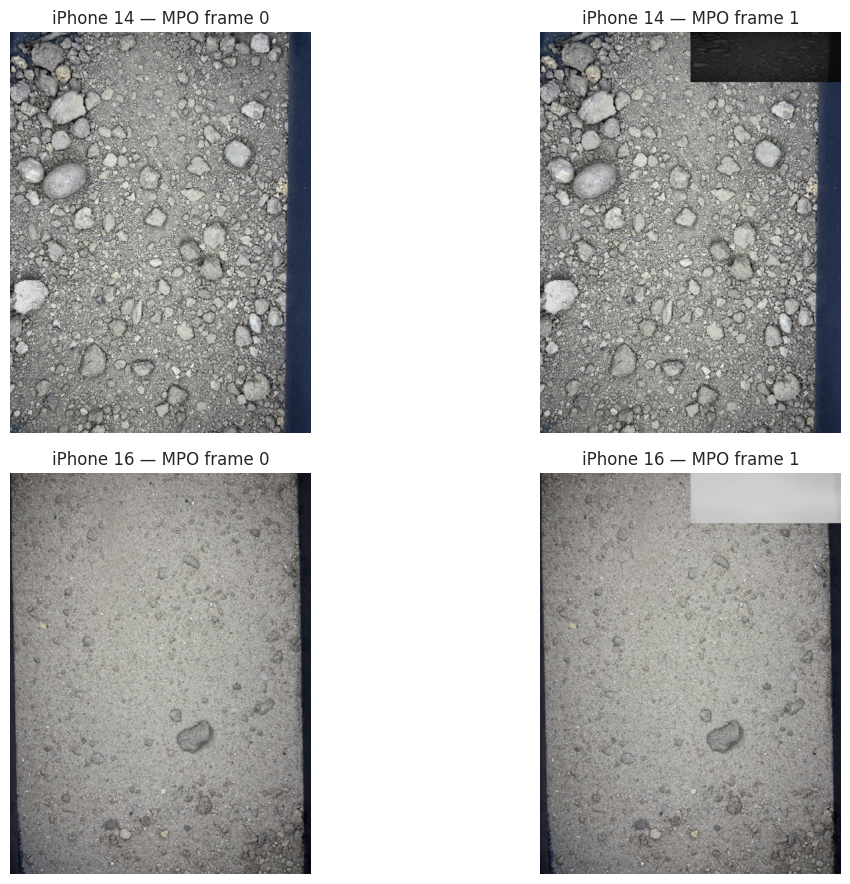

In [8]:
mpo_examples = all_images[all_images["split"].eq("test")].drop_duplicates("phone")
frame_info, previews = [], []

for row in mpo_examples.itertuples(index=False):
    with Image.open(row.path) as im:
        for frame_number in range(getattr(im, "n_frames", 1)):
            im.seek(frame_number)
            frame = ImageOps.exif_transpose(im).convert("RGB")
            frame_info.append({"phone": row.phone, "filename": row.filename, "frame": frame_number,
                               "width": frame.width, "height": frame.height, "mode": frame.mode})
            frame.thumbnail((800, 600))
            previews.append((row.phone, frame_number, frame.copy()))

display(pd.DataFrame(frame_info))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (phone, frame_number, frame) in zip(axes.ravel(), previews):
    ax.imshow(frame)
    ax.set_title(f"{phone} — MPO frame {frame_number}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
LOG_WEIGHTS = np.diff(np.log10(GRAIN_SIZES))

def emd_per_sample(y_true, y_pred):
    return (np.abs(y_true[:, :-1] - y_pred[:, :-1]) * LOG_WEIGHTS).sum(axis=1)

def emd_score(y_true, y_pred):
    return emd_per_sample(y_true, y_pred).mean()

metric_intervals = pd.DataFrame({
    "left_mm": GRAIN_SIZES[:-1], "right_mm": GRAIN_SIZES[1:],
    "log_weight": LOG_WEIGHTS
})

n_samples = len(targets)
equal_curve = np.arange(1, 12) * 100 / 11
mean_curve, median_curve = targets.mean(axis=0), np.median(targets, axis=0)
loo_mean = (targets.sum(axis=0) - targets) / (n_samples - 1)
loo_median = np.vstack([np.median(np.delete(targets, i, axis=0), axis=0) for i in range(n_samples)])

baseline_specs = [
    ("Equal-bin competition baseline", np.tile(equal_curve, (n_samples, 1)), "training samples"),
    ("Training mean curve", np.tile(mean_curve, (n_samples, 1)), "in-sample"),
    ("Training median curve", np.tile(median_curve, (n_samples, 1)), "in-sample"),
    ("Leave-one-out mean curve", loo_mean, "out-of-sample"),
    ("Leave-one-out median curve", loo_median, "out-of-sample")
]
baseline_scores = pd.DataFrame([{"baseline": name, "evaluation": evaluation, "EMD": emd_score(targets, prediction)}
                                for name, prediction, evaluation in baseline_specs]).sort_values("EMD")

d50_values = np.array([diameter_at_percent(cdf) for cdf in targets])
difficulty = pd.DataFrame({
    "sample_id": train_ids, "D50_mm": d50_values,
    "LOO_mean_EMD": emd_per_sample(targets, loo_mean),
    "LOO_median_EMD": emd_per_sample(targets, loo_median)
}).sort_values("LOO_median_EMD", ascending=False)

print(f"Sum of logarithmic weights: {LOG_WEIGHTS.sum():.4f}")
display(metric_intervals.round(4))
print("Constant-curve baselines")
display(baseline_scores.round(3))
print("Samples least well represented by the other target curves")
display(difficulty.round(3))

Sum of logarithmic weights: 5.0000


,left_mm,right_mm,log_weight
0,0.0020,0.0063,0.4983
1,0.0063,0.0200,0.5017
2,0.0200,0.0630,0.4983
3,0.0630,0.2000,0.5017
4,0.2000,0.6300,0.4983
5,0.6300,2.0000,0.5017
6,2.0000,6.3000,0.4983
7,6.3000,20.0000,0.5017
8,20.0000,63.0000,0.4983
9,63.0000,200.0000,0.5017


Constant-curve baselines


,baseline,evaluation,EMD
2,Training median curve,in-sample,83.247
1,Training mean curve,in-sample,86.143
3,Leave-one-out mean curve,out-of-sample,89.889
4,Leave-one-out median curve,out-of-sample,97.248
0,Equal-bin competition baseline,training samples,102.023


Samples least well represented by the other target curves


,sample_id,D50_mm,LOO_mean_EMD,LOO_median_EMD
0,F827,0.021,142.559,176.192
14,H405,0.022,135.618,169.540
17,H549,0.030,117.287,151.973
23,H668,0.030,115.819,150.566
5,H126,0.035,102.063,137.383
15,H493,0.059,93.345,127.616
22,H666,0.068,92.662,120.131
1,G190,0.062,74.510,110.978
2,H030,0.103,74.205,110.686
20,H617,0.099,68.150,98.526


PCA of the first ten cumulative targets


,component,explained_variance,cumulative_variance
0,1,0.9143,0.9143
1,2,0.0620,0.9763
2,3,0.0138,0.9901
3,4,0.0065,0.9966
4,5,0.0019,0.9985
5,6,0.0010,0.9995


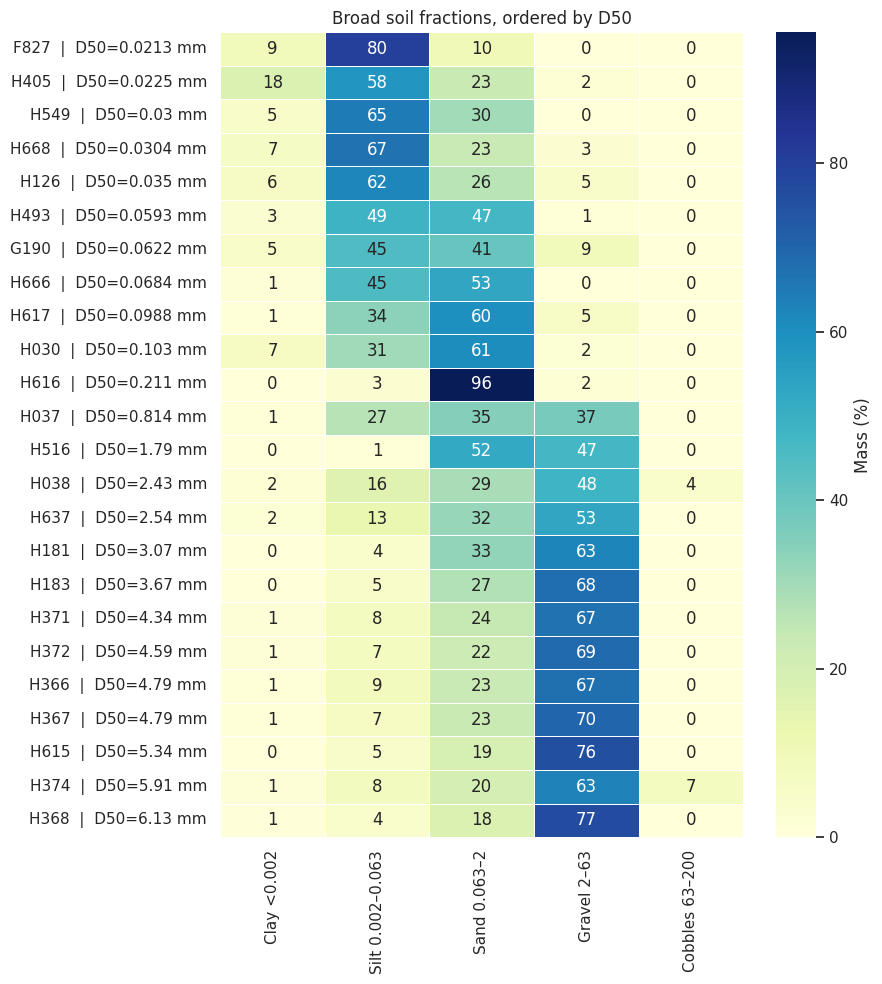

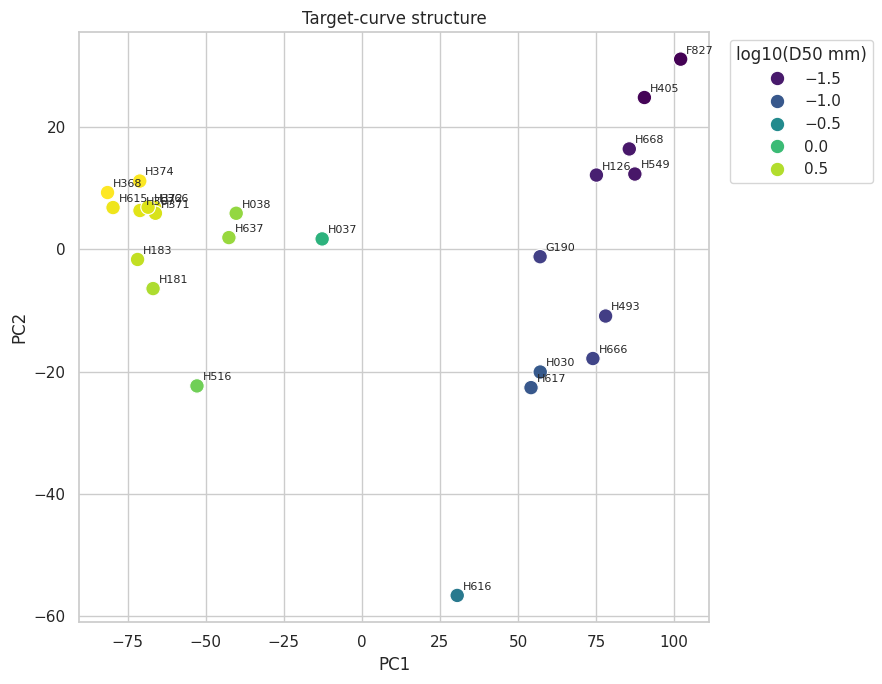

In [10]:
from sklearn.decomposition import PCA

soil_fractions = pd.DataFrame({
    "Clay <0.002": targets[:, 0],
    "Silt 0.002–0.063": targets[:, 3] - targets[:, 0],
    "Sand 0.063–2": targets[:, 6] - targets[:, 3],
    "Gravel 2–63": targets[:, 9] - targets[:, 6],
    "Cobbles 63–200": 100 - targets[:, 9]
}, index=train_ids)

sample_order = np.argsort(d50_values)
fraction_plot = soil_fractions.iloc[sample_order].copy()
fraction_plot.index = [f"{train_ids[i]}  |  D50={d50_values[i]:.3g} mm" for i in sample_order]

pca = PCA().fit(targets[:, :-1])
pca_scores = pca.transform(targets[:, :-1])
pca_summary = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})
pca_frame = pd.DataFrame({"sample_id": train_ids, "PC1": pca_scores[:, 0], "PC2": pca_scores[:, 1],
                          "D50_mm": d50_values, "log10_D50": np.log10(d50_values)})

print("PCA of the first ten cumulative targets")
display(pca_summary.head(6).round(4))

plt.figure(figsize=(9, 10))
sns.heatmap(fraction_plot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.4, cbar_kws={"label": "Mass (%)"})
plt.title("Broad soil fractions, ordered by D50")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=pca_frame, x="PC1", y="PC2", hue="log10_D50", palette="viridis", s=110, ax=ax)
for row in pca_frame.itertuples(index=False):
    ax.annotate(row.sample_id, (row.PC1, row.PC2), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_title("Target-curve structure")
ax.legend(title="log10(D50 mm)", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import StratifiedKFold

camera_info = all_images[all_images["split"].eq("train")].groupby("sample_id", as_index=False).agg(
    cameras=("phone", "nunique"), phones=("phone", lambda s: " + ".join(sorted(s.unique()))))
fraction_info = soil_fractions.rename_axis("sample_id").reset_index()

sample_df = pd.DataFrame({
    "sample_id": train_ids, "D50_mm": d50_values, "PC1": pca_scores[:, 0], "PC2": pca_scores[:, 1],
    "LOO_mean_EMD": emd_per_sample(targets, loo_mean)
})
sample_df = sample_df.merge(fraction_info, on="sample_id").merge(camera_info, on="sample_id")
sample_df["stratum"] = pd.qcut(sample_df["D50_mm"], 4, labels=["fine", "fine-medium", "medium-coarse", "coarse"])
sample_df["fold"] = -1

splitter = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
for fold, (_, valid_idx) in enumerate(splitter.split(sample_df, sample_df["stratum"])):
    sample_df.loc[valid_idx, "fold"] = fold

global_curve = targets.mean(axis=0, keepdims=True)
fold_balance = sample_df.groupby("fold", as_index=False).agg(
    samples=("sample_id", "size"), D50_min=("D50_mm", "min"), D50_median=("D50_mm", "median"),
    D50_max=("D50_mm", "max"), PC1_mean=("PC1", "mean"), PC2_mean=("PC2", "mean"),
    single_camera_samples=("cameras", lambda s: (s == 1).sum()), constant_EMD=("LOO_mean_EMD", "mean"))
fold_balance["centroid_EMD"] = [
    emd_per_sample(global_curve, targets[sample_df["fold"].eq(fold)].mean(axis=0, keepdims=True))[0] for fold in fold_balance["fold"]
]

print("Sample assignments")
display(sample_df.sort_values(["fold", "D50_mm"]).round(3))
print("D50 strata per fold")
display(pd.crosstab(sample_df["fold"], sample_df["stratum"]))
print("Fold balance")
display(fold_balance.round(3))

Sample assignments


,sample_id,D50_mm,PC1,PC2,LOO_mean_EMD,Clay <0.002,Silt 0.002–0.063,Sand 0.063–2,Gravel 2–63,Cobbles 63–200,cameras,phones,stratum,fold
0,F827,0.021,102.104,31.087,142.559,9.490,80.065,10.445,0.000,0.000,2,Motorola Edge + Samsung A52,fine,0
2,H030,0.103,57.122,-20.050,74.205,6.783,30.540,60.630,2.047,0.000,2,Motorola Edge + Samsung A52,fine-medium,0
7,H183,3.674,-71.868,-1.654,92.484,0.000,4.949,27.332,67.719,0.000,2,Motorola Edge + Samsung A52,medium-coarse,0
8,H366,4.791,-66.376,6.849,87.497,0.963,8.520,23.334,67.183,0.000,1,Motorola Edge,coarse,0
5,H126,0.035,75.119,12.141,102.063,6.333,62.027,26.487,5.153,0.000,2,Motorola Edge + Samsung A52,fine,1
3,H037,0.814,-12.735,1.706,17.530,0.932,26.870,34.915,37.283,0.000,2,Motorola Edge + Samsung A52,fine-medium,1
6,H181,3.066,-66.903,-6.414,85.689,0.000,4.296,33.111,62.593,0.000,2,Motorola Edge + Samsung A52,medium-coarse,1
12,H372,4.585,-68.499,6.885,87.660,1.202,7.491,22.362,68.944,0.000,2,Motorola Edge + Samsung A52,coarse,1
15,H493,0.059,78.063,-10.900,93.345,3.275,48.673,47.262,0.790,0.000,2,Motorola Edge + Samsung A52,fine,2
19,H616,0.211,30.528,-56.566,80.524,0.000,2.781,95.542,1.678,0.000,2,Motorola Edge + Samsung A52,fine-medium,2


D50 strata per fold


stratum,fine,fine-medium,medium-coarse,coarse
fold,,,,
0,1,1,1,1
1,1,1,1,1
2,1,1,1,1
3,1,1,1,1
4,1,1,1,1
5,1,1,1,1


Fold balance


,fold,samples,D50_min,D50_median,D50_max,PC1_mean,PC2_mean,single_camera_samples,constant_EMD,centroid_EMD
0,0,4,0.021,1.889,4.791,5.245,4.058,1,99.186,9.668
1,1,4,0.035,1.940,4.585,-18.254,3.579,0,73.236,20.569
2,2,4,0.059,1.373,5.339,-3.437,-14.678,1,84.204,18.316
3,3,4,0.030,2.200,6.126,-1.227,7.599,0,95.729,10.431
4,4,4,0.030,1.251,5.911,12.493,2.881,1,91.997,18.331
5,5,4,0.022,0.947,4.792,5.180,-3.440,0,94.981,10.985


In [12]:
single_camera_idx = np.flatnonzero(sample_df["cameras"].eq(1))
cobble_idx = np.flatnonzero(sample_df["Cobbles 63–200"].gt(0.1))
best_key, best_seed, best_folds = None, None, None

for seed in tqdm(range(5000), desc="Searching balanced folds"):
    fold_ids = np.full(len(sample_df), -1)
    splitter = StratifiedKFold(n_splits=6, shuffle=True, random_state=seed)
    for fold, (_, valid_idx) in enumerate(splitter.split(sample_df, sample_df["stratum"])):
        fold_ids[valid_idx] = fold

    if len(np.unique(fold_ids[single_camera_idx])) < len(single_camera_idx): continue
    if len(np.unique(fold_ids[cobble_idx])) < len(cobble_idx): continue

    centroid_emd = np.array([
        emd_per_sample(global_curve, targets[fold_ids == fold].mean(axis=0, keepdims=True))[0] for fold in range(6)
    ])
    key = (centroid_emd.max(), centroid_emd.std(), centroid_emd.mean())
    if best_key is None or key < best_key:
        best_key, best_seed, best_folds = key, seed, fold_ids.copy()

FOLD_SEED = best_seed
sample_df["fold"] = best_folds
all_images["fold"] = all_images["sample_id"].map(sample_df.set_index("sample_id")["fold"])

fold_balance = sample_df.groupby("fold", as_index=False).agg(
    samples=("sample_id", "size"), D50_min=("D50_mm", "min"), D50_median=("D50_mm", "median"),
    D50_max=("D50_mm", "max"), PC1_mean=("PC1", "mean"), PC2_mean=("PC2", "mean"),
    single_camera_samples=("cameras", lambda s: (s == 1).sum()), constant_EMD=("LOO_mean_EMD", "mean"))
fold_balance["centroid_EMD"] = [
    emd_per_sample(global_curve, targets[sample_df["fold"].eq(fold)].mean(axis=0, keepdims=True))[0] for fold in fold_balance["fold"]
]

print(f"Selected seed: {FOLD_SEED}")
print("Constrained samples")
display(sample_df[(sample_df["cameras"].eq(1)) | (sample_df["Cobbles 63–200"].gt(0.1))][
    ["sample_id", "D50_mm", "Cobbles 63–200", "cameras", "phones", "fold"]].sort_values("fold").round(3))
print("Final sample assignments")
display(sample_df[["sample_id", "D50_mm", "PC1", "PC2", "stratum", "cameras", "fold"]].sort_values(["fold", "D50_mm"]).round(3))
print("Final fold balance")
display(fold_balance.round(3))

sample_df.to_csv("/kaggle/working/sample_folds.csv", index=False)

Searching balanced folds:   0%|          | 0/5000 [00:00<?, ?it/s]

Selected seed: 2385
Constrained samples


,sample_id,D50_mm,Cobbles 63–200,cameras,phones,fold
21,H637,2.535,0.000,1,Samsung A52,1
8,H366,4.791,0.000,1,Motorola Edge,2
13,H374,5.911,7.360,1,Motorola Edge 60 Fusion,3
4,H038,2.434,4.287,2,Motorola Edge + Samsung A52,4


Final sample assignments


,sample_id,D50_mm,PC1,PC2,stratum,cameras,fold
5,H126,0.035,75.119,12.141,fine,2,0
22,H666,0.068,73.992,-17.844,fine-medium,2,0
7,H183,3.674,-71.868,-1.654,medium-coarse,2,0
12,H372,4.585,-68.499,6.885,coarse,2,0
14,H405,0.022,90.487,24.817,fine,2,1
2,H030,0.103,57.122,-20.050,fine-medium,2,1
21,H637,2.535,-42.614,1.922,medium-coarse,1,1
18,H615,5.339,-79.726,6.831,coarse,2,1
0,F827,0.021,102.104,31.087,fine,2,2
3,H037,0.814,-12.735,1.706,fine-medium,2,2


Final fold balance


,fold,samples,D50_min,D50_median,D50_max,PC1_mean,PC2_mean,single_camera_samples,constant_EMD,centroid_EMD
0,0,4,0.035,1.871,4.585,2.186,-0.118,0,93.718,7.706
1,1,4,0.022,1.319,5.339,6.317,3.380,1,93.193,12.256
2,2,4,0.021,1.305,4.791,-7.461,4.330,1,82.647,13.669
3,3,4,0.030,2.200,5.911,1.352,8.068,1,94.197,12.097
4,4,4,0.030,1.322,6.126,-0.952,-7.268,0,90.494,12.006
5,5,4,0.059,1.582,4.792,-1.442,-8.392,0,85.085,12.225


- The dataset contains 24 labeled samples with 127 images and 10 test samples with 35 images. Validation splits must be grouped by soil sample.
- Targets are clean, monotonic cumulative distributions. Visible soil texture is strongly related to grain size, although `D50` does not capture every curve shape.
- A camera and resolution shift is present between training and test data. Test MPO files should be read from frame 0 only.
- Six balanced sample-level folds are defined using seed `2385`, preserving target diversity and separating camera and cobble edge cases.

# 2. Modeling

- Frozen DINOv2 Baseline

Physically normalized soil patches are encoded using a pretrained DINOv2 backbone. Features are aggregated by soil sample and evaluated with the official logarithmically weighted EMD.

In [13]:
import torch, timm

if "feature_extractor" in globals(): del feature_extractor
if "backbone" in globals(): del backbone
torch.cuda.empty_cache()

MODEL_NAME = "vit_small_patch14_reg4_dinov2.lvd142m"
backbone = timm.create_model(MODEL_NAME, pretrained=True, num_classes=0)
model_config = timm.data.resolve_model_data_config(backbone)
feature_dim = backbone.num_features
parameter_count = sum(parameter.numel() for parameter in backbone.parameters()) / 1e6

feature_extractor = backbone.eval().cuda()
if torch.cuda.device_count() > 1:
    feature_extractor = torch.nn.DataParallel(feature_extractor)

with torch.inference_mode(), torch.autocast("cuda", dtype=torch.float16):
    dummy_features = feature_extractor(torch.randn(2, *model_config["input_size"], device="cuda"))

print(f"Model: {MODEL_NAME} | Parameters: {parameter_count:.1f}M")
print(f"Input configuration: {model_config}")
print(f"GPUs: {torch.cuda.device_count()} | Feature shape: {tuple(dummy_features.shape)}")
del dummy_features
torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Model: vit_small_patch14_reg4_dinov2.lvd142m | Parameters: 22.1M
Input configuration: {'input_size': (3, 518, 518), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 1.0, 'crop_mode': 'center'}
GPUs: 2 | Feature shape: (2, 384)


In [14]:
from PIL import Image, ImageOps
from torch.utils.data import Dataset
from torchvision import transforms

TARGET_PPM = 5.0
PATCH_SIZE = model_config["input_size"][-1]
LONG_MARGIN = .12
CROP_POSITIONS = [("long_1", 0), ("long_2", .25), ("center", .5), ("long_4", .75), ("long_5", 1)]
image_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(model_config["mean"], model_config["std"])])

def load_canonical_image(row):
    with Image.open(row["path"]) as im:
        im.seek(0)
        image = ImageOps.exif_transpose(im).convert("RGB")
    scale = TARGET_PPM / row["estimated_ppm"]
    return image.resize((round(image.width * scale), round(image.height * scale)), Image.Resampling.LANCZOS)

def make_physical_patches(image):
    width, height = image.size
    long_side, short_side = max(width, height), min(width, height)
    margin = max(0, min(int(short_side * LONG_MARGIN), (long_side - PATCH_SIZE) // 2))
    long_span, short_start = max(long_side - PATCH_SIZE - 2 * margin, 0), max((short_side - PATCH_SIZE) // 2, 0)
    patches = []

    for _, position in CROP_POSITIONS:
        long_start = round(margin + position * long_span)
        box = (long_start, short_start, long_start + PATCH_SIZE, short_start + PATCH_SIZE) if width >= height else (
               short_start, long_start, short_start + PATCH_SIZE, long_start + PATCH_SIZE)
        patches.append(image.crop(box))
    return patches

class PhysicalCropDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        image = load_canonical_image(self.frame.iloc[index])
        patches = torch.stack([image_transform(patch) for patch in make_physical_patches(image)])
        return patches, index

image_df = all_images.sort_values(["split", "sample_id", "filename"]).reset_index(drop=True)
physical_dataset = PhysicalCropDataset(image_df)

print(f"Images: {len(physical_dataset)} | Patches per image: {len(CROP_POSITIONS)}")
print(f"Patch size: {PATCH_SIZE}px | Physical coverage: {PATCH_SIZE / TARGET_PPM:.1f} mm")

Images: 162 | Patches per image: 5
Patch size: 518px | Physical coverage: 103.6 mm


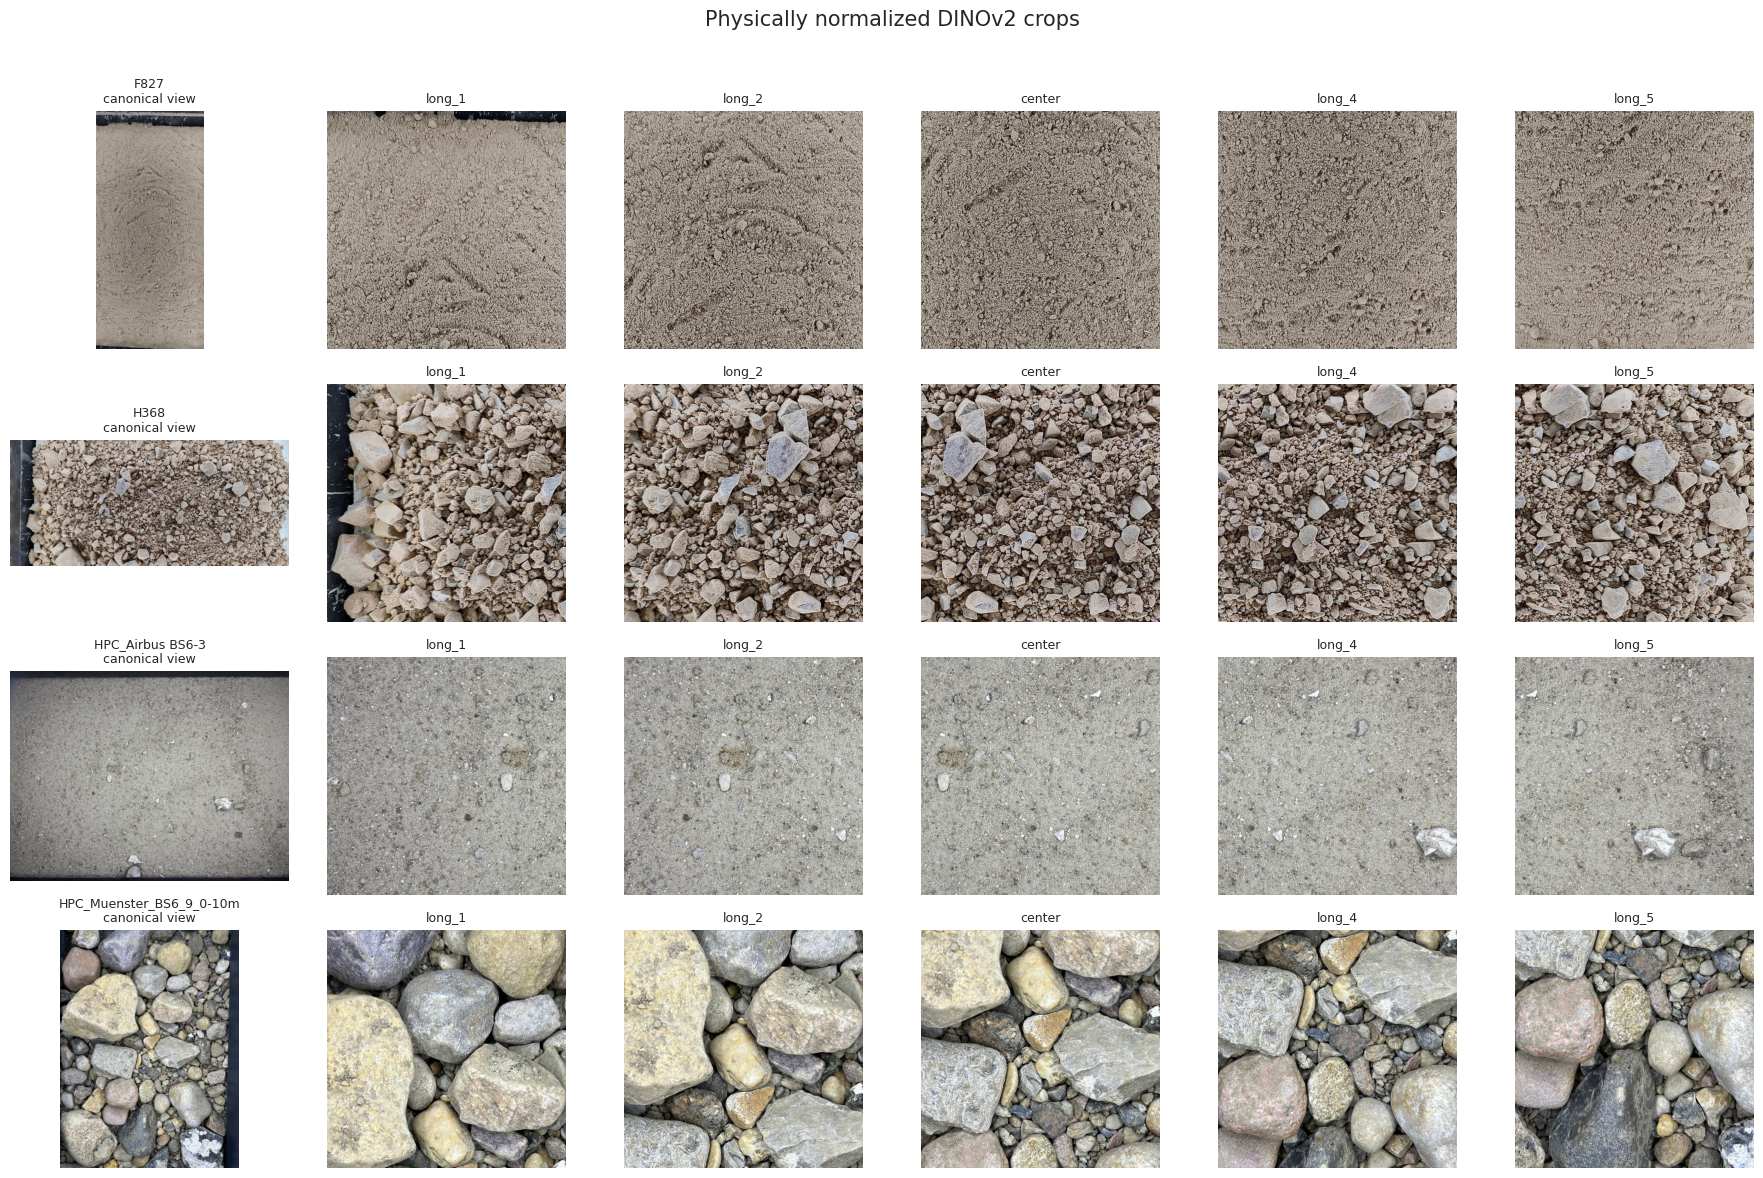

In [15]:
preview_samples = ["F827", "H368", "HPC_Airbus BS6-3", "HPC_Muenster_BS6_9_0-10m"]
fig, axes = plt.subplots(len(preview_samples), len(CROP_POSITIONS) + 1, figsize=(18, 12))

for row_number, sample_id in enumerate(preview_samples):
    row = image_df[image_df["sample_id"].eq(sample_id)].iloc[0]
    canonical = load_canonical_image(row)
    patches = make_physical_patches(canonical)
    full_view = canonical.copy()
    full_view.thumbnail((600, 500))

    axes[row_number, 0].imshow(full_view)
    axes[row_number, 0].set_title(f"{sample_id}\ncanonical view", fontsize=9)
    axes[row_number, 0].axis("off")

    for column, ((crop_name, _), patch) in enumerate(zip(CROP_POSITIONS, patches), start=1):
        axes[row_number, column].imshow(patch)
        axes[row_number, column].set_title(crop_name, fontsize=9)
        axes[row_number, column].axis("off")

plt.suptitle("Physically normalized DINOv2 crops", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, .97])
plt.show()

In [16]:
from time import perf_counter
from torch.utils.data import DataLoader

IMAGE_BATCH_SIZE = 4
NUM_WORKERS = 4
feature_loader = DataLoader(physical_dataset, batch_size=IMAGE_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=True, persistent_workers=True)
physical_features = np.empty((len(physical_dataset), len(CROP_POSITIONS), feature_dim), dtype=np.float32)
start = perf_counter()

with torch.inference_mode():
    for patches, indices in tqdm(feature_loader, desc="Extracting DINOv2 features"):
        batch_size, views = patches.shape[:2]
        patches = patches.flatten(0, 1).cuda(non_blocking=True)
        with torch.autocast("cuda", dtype=torch.float16):
            batch_features = feature_extractor(patches)
        physical_features[indices.numpy()] = batch_features.float().cpu().numpy().reshape(batch_size, views, feature_dim)

elapsed = (perf_counter() - start) / 60
feature_norms = np.linalg.norm(physical_features, axis=-1)
FEATURE_PATH = "/kaggle/working/dinov2_physical_features.npz"

np.savez_compressed(FEATURE_PATH, features=physical_features, sample_ids=image_df["sample_id"].to_numpy(),
                    paths=image_df["path"].to_numpy(), crop_names=np.array([name for name, _ in CROP_POSITIONS]))

print(f"Feature shape: {physical_features.shape} | Finite: {np.isfinite(physical_features).all()}")
print(f"Feature norms — min: {feature_norms.min():.3f} | median: {np.median(feature_norms):.3f} | max: {feature_norms.max():.3f}")
print(f"Extraction time: {elapsed:.2f} minutes")

Extracting DINOv2 features:   0%|          | 0/41 [00:00<?, ?it/s]

Feature shape: (162, 5, 384) | Finite: True
Feature norms — min: 24.356 | median: 26.062 | max: 28.392
Extraction time: 0.45 minutes


In [17]:
from itertools import product
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

all_sample_ids = train_ids + test_ids
normalized_features = physical_features / np.linalg.norm(physical_features, axis=-1, keepdims=True)

def aggregate_features(features, include_std=False):
    pooled = []
    for sample_id in all_sample_ids:
        sample_views = features[image_df["sample_id"].eq(sample_id).to_numpy()].reshape(-1, features.shape[-1])
        values = [sample_views.mean(axis=0)]
        if include_std: values.append(sample_views.std(axis=0))
        pooled.append(np.concatenate(values))
    return np.vstack(pooled)

def make_valid_cdf(prediction):
    prediction = np.clip(prediction, 0, 100)
    prediction = np.maximum.accumulate(prediction, axis=1)
    prediction[:, -1] = 100
    return prediction

feature_sets = {
    "raw_mean": aggregate_features(physical_features),
    "normalized_mean": aggregate_features(normalized_features),
    "normalized_mean_std": aggregate_features(normalized_features, include_std=True)
}

folds = sample_df.set_index("sample_id").loc[train_ids, "fold"].astype(int).to_numpy()
alphas = [.1, 1, 10, 100, 1000, 10000]
target_modes = {"direct": None, "pca_2": 2, "pca_3": 3}
experiments = list(product(feature_sets, target_modes, alphas))
results, oof_predictions = [], {}

for feature_name, target_mode, alpha in tqdm(experiments, desc="Evaluating frozen features"):
    X, oof = feature_sets[feature_name][:len(train_ids)], np.zeros_like(targets)

    for fold in range(6):
        train_idx, valid_idx = folds != fold, folds == fold
        model = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))

        if target_modes[target_mode] is None:
            model.fit(X[train_idx], targets[train_idx, :-1])
            pred = model.predict(X[valid_idx])
        else:
            target_pca = PCA(n_components=target_modes[target_mode]).fit(targets[train_idx, :-1])
            model.fit(X[train_idx], target_pca.transform(targets[train_idx, :-1]))
            pred = target_pca.inverse_transform(model.predict(X[valid_idx]))

        pred = np.column_stack([pred, np.full(valid_idx.sum(), 100.0)])
        oof[valid_idx] = make_valid_cdf(pred)

    key = (feature_name, target_mode, float(alpha))
    results.append({"features": feature_name, "targets": target_mode, "alpha": alpha, "OOF_EMD": emd_score(targets, oof)})
    oof_predictions[key] = oof

results = pd.DataFrame(results).sort_values("OOF_EMD").reset_index(drop=True)
best = results.iloc[0]
best_key = (str(best["features"]), str(best["targets"]), float(best["alpha"]))
best_oof = oof_predictions[best_key]

oof_details = pd.DataFrame({
    "sample_id": train_ids, "fold": folds,
    "OOF_EMD": emd_per_sample(targets, best_oof)
}).sort_values("OOF_EMD", ascending=False)

display(results.head(15).round(3))
print(f"Best configuration: {best_key} | OOF EMD: {best['OOF_EMD']:.3f}")
display(oof_details.round(3))

Evaluating frozen features:   0%|          | 0/54 [00:00<?, ?it/s]

,features,targets,alpha,OOF_EMD
0,normalized_mean_std,pca_2,10.0,40.968
1,normalized_mean_std,pca_2,1.0,40.971
2,normalized_mean_std,pca_2,0.1,40.972
3,normalized_mean_std,direct,10.0,41.058
4,normalized_mean_std,direct,1.0,41.075
5,normalized_mean_std,direct,0.1,41.078
6,normalized_mean_std,direct,100.0,41.081
7,normalized_mean_std,pca_2,100.0,41.141
8,normalized_mean_std,pca_3,100.0,41.400
9,normalized_mean_std,pca_3,10.0,41.456


Best configuration: ('normalized_mean_std', 'pca_2', 10.0) | OOF EMD: 40.968


,sample_id,fold,OOF_EMD
4,H038,4,132.974
14,H405,1,120.300
3,H037,2,80.268
19,H616,4,66.842
5,H126,0,57.484
16,H516,2,53.644
0,F827,2,46.444
13,H374,3,45.781
23,H668,3,44.277
15,H493,5,42.452


Performance by fold


,fold,samples,EMD,median_sample_EMD,max_sample_EMD
0,0,4,27.592,23.801,57.484
1,1,4,48.839,28.333,120.300
2,2,4,49.560,50.044,80.268
3,3,4,32.419,36.501,45.781
4,4,4,60.979,48.198,132.974
5,5,4,26.416,21.342,42.452


Performance by grain-size threshold


,diameter_mm,MAE,EMD_contribution
0,0.002,2.561,1.276
1,0.006,4.372,2.193
2,0.020,9.207,4.588
3,0.063,16.273,8.164
4,0.200,16.854,8.399
5,0.630,11.389,5.714
6,2.000,8.522,4.247
7,6.300,7.488,3.757
8,20.000,4.331,2.158
9,63.000,0.941,0.472


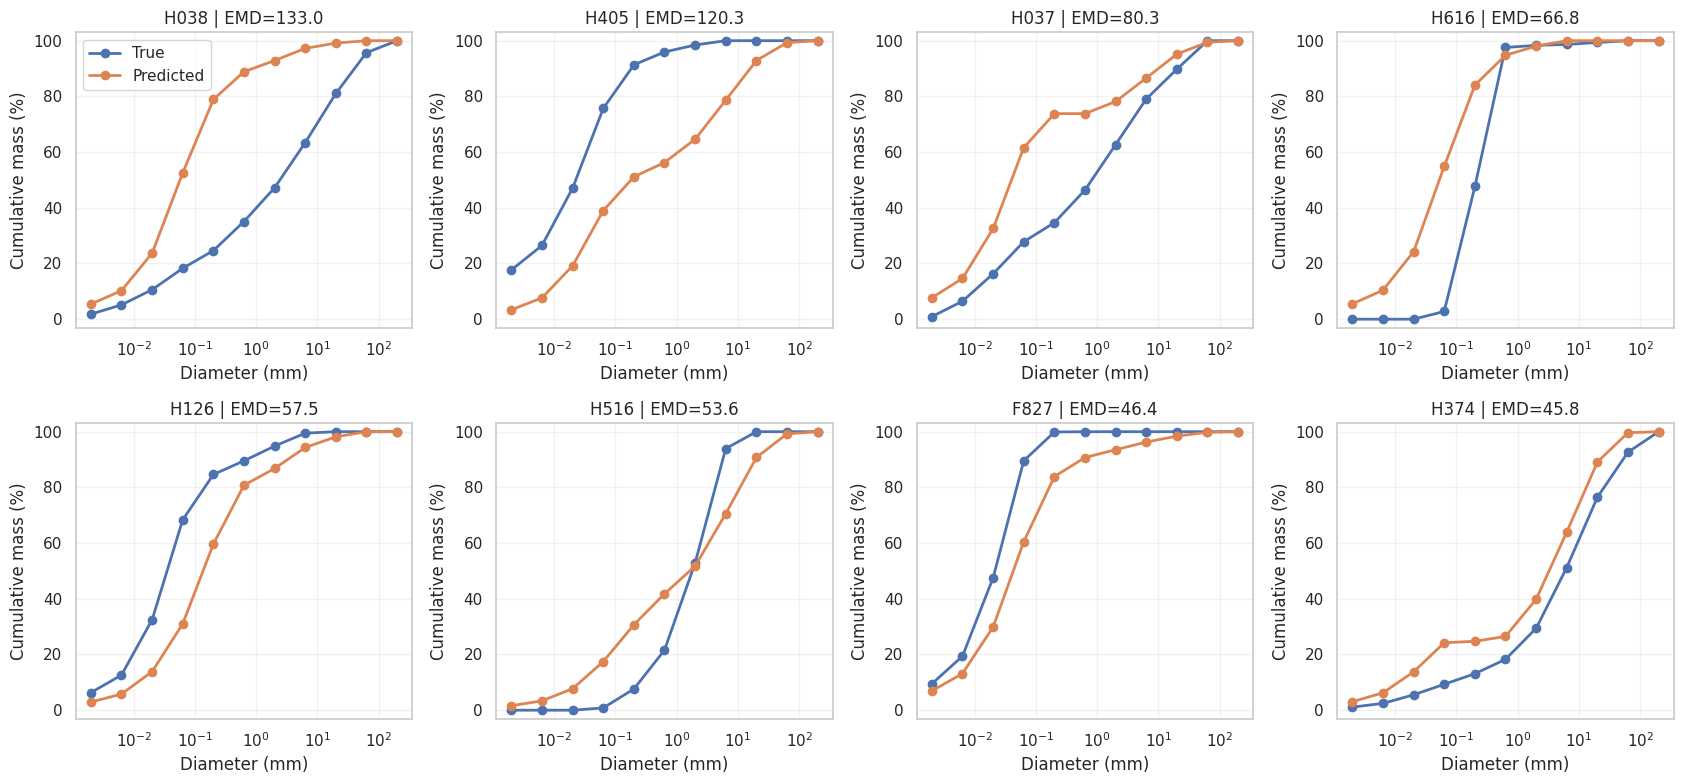

In [18]:
sample_errors = emd_per_sample(targets, best_oof)

fold_summary = pd.DataFrame([
    {
        "fold": fold,
        "samples": (folds == fold).sum(),
        "EMD": emd_score(targets[folds == fold], best_oof[folds == fold]),
        "median_sample_EMD": np.median(sample_errors[folds == fold]),
        "max_sample_EMD": sample_errors[folds == fold].max()
    }
    for fold in range(6)
])

threshold_summary = pd.DataFrame({
    "diameter_mm": GRAIN_SIZES[:-1],
    "MAE": np.abs(targets[:, :-1] - best_oof[:, :-1]).mean(axis=0),
    "EMD_contribution": np.abs(targets[:, :-1] - best_oof[:, :-1]).mean(axis=0) * LOG_WEIGHTS
})

print("Performance by fold")
display(fold_summary.round(3))
print("Performance by grain-size threshold")
display(threshold_summary.round(3))

worst_indices = np.argsort(sample_errors)[::-1][:8]
fig, axes = plt.subplots(2, 4, figsize=(17, 8))

for ax, index in zip(axes.ravel(), worst_indices):
    ax.plot(GRAIN_SIZES, targets[index], marker="o", linewidth=2, label="True")
    ax.plot(GRAIN_SIZES, best_oof[index], marker="o", linewidth=2, label="Predicted")
    ax.set_xscale("log")
    ax.set_ylim(-3, 103)
    ax.set_title(f"{train_ids[index]} | EMD={sample_errors[index]:.1f}")
    ax.set_xlabel("Diameter (mm)")
    ax.set_ylabel("Cumulative mass (%)")
    ax.grid(alpha=.25)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

## Crop-subset ablation

In [19]:
CROP_SUBSETS = {
    "center": [2],
    "interior_3": [1, 2, 3],
    "without_long_1": [1, 2, 3, 4],
    "all_5": [0, 1, 2, 3, 4]
}

def aggregate_crop_subset(crop_indices):
    pooled = []
    for sample_id in all_sample_ids:
        sample_images = normalized_features[image_df["sample_id"].eq(sample_id).to_numpy()]
        sample_views = sample_images[:, crop_indices].reshape(-1, feature_dim)
        pooled.append(np.concatenate([sample_views.mean(axis=0), sample_views.std(axis=0)]))
    return np.vstack(pooled)

def ridge_oof(X, target_mode, alpha):
    oof = np.zeros_like(targets)

    for fold in range(6):
        train_idx, valid_idx = folds != fold, folds == fold
        model = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))

        if target_modes[target_mode] is None:
            model.fit(X[train_idx], targets[train_idx, :-1])
            pred = model.predict(X[valid_idx])
        else:
            target_pca = PCA(n_components=target_modes[target_mode]).fit(targets[train_idx, :-1])
            model.fit(X[train_idx], target_pca.transform(targets[train_idx, :-1]))
            pred = target_pca.inverse_transform(model.predict(X[valid_idx]))

        oof[valid_idx] = make_valid_cdf(np.column_stack([pred, np.full(valid_idx.sum(), 100.0)]))
    return oof

crop_feature_sets = {name: aggregate_crop_subset(indices) for name, indices in CROP_SUBSETS.items()}
ablation_experiments = list(product(crop_feature_sets, ["direct", "pca_2", "pca_3"], [1, 10, 100]))
ablation_rows, ablation_predictions = [], {}

for crops, target_mode, alpha in tqdm(ablation_experiments, desc="Evaluating crop subsets"):
    oof = ridge_oof(crop_feature_sets[crops][:len(train_ids)], target_mode, alpha)
    key = (crops, target_mode, float(alpha))
    ablation_rows.append({"crops": crops, "targets": target_mode, "alpha": alpha, "OOF_EMD": emd_score(targets, oof)})
    ablation_predictions[key] = oof

ablation_results = pd.DataFrame(ablation_rows).sort_values("OOF_EMD").reset_index(drop=True)
best_ablation = ablation_results.iloc[0]
best_ablation_key = (str(best_ablation["crops"]), str(best_ablation["targets"]), float(best_ablation["alpha"]))

display(ablation_results.head(15).round(3))
print(f"Best crop configuration: {best_ablation_key} | OOF EMD: {best_ablation['OOF_EMD']:.3f}")

Evaluating crop subsets:   0%|          | 0/36 [00:00<?, ?it/s]

,crops,targets,alpha,OOF_EMD
0,without_long_1,direct,1,38.135
1,without_long_1,direct,10,38.159
2,without_long_1,pca_3,1,38.493
3,without_long_1,pca_3,10,38.501
4,without_long_1,pca_2,1,38.535
5,without_long_1,pca_2,10,38.549
6,without_long_1,direct,100,38.643
7,without_long_1,pca_3,100,38.820
8,without_long_1,pca_2,100,38.879
9,interior_3,direct,1,40.454


Best crop configuration: ('without_long_1', 'direct', 1.0) | OOF EMD: 38.135


In [20]:
from itertools import combinations

candidate_oof = {
    "PCA2 all crops": oof_predictions[("normalized_mean_std", "pca_2", 10.0)],
    "Direct all crops": oof_predictions[("normalized_mean_std", "direct", 10.0)],
    "PCA3 all crops": oof_predictions[("normalized_mean_std", "pca_3", 100.0)],
    "Best crop ablation": ablation_predictions[best_ablation_key]
}

blend_rows, blend_predictions = [], {}

for name, prediction in candidate_oof.items():
    blend_rows.append({"model": name, "OOF_EMD": emd_score(targets, prediction)})
    blend_predictions[name] = prediction

for (name_a, pred_a), (name_b, pred_b) in combinations(candidate_oof.items(), 2):
    for weight_a in [.25, .5, .75]:
        name = f"{weight_a:.2f} {name_a} + {1 - weight_a:.2f} {name_b}"
        prediction = make_valid_cdf(weight_a * pred_a + (1 - weight_a) * pred_b)
        blend_rows.append({"model": name, "OOF_EMD": emd_score(targets, prediction)})
        blend_predictions[name] = prediction

blend_results = pd.DataFrame(blend_rows).sort_values("OOF_EMD").reset_index(drop=True)
best_blend_name = blend_results.iloc[0]["model"]
best_blend_oof = blend_predictions[best_blend_name]

comparison = pd.DataFrame({
    "sample_id": train_ids,
    "PCA2_EMD": emd_per_sample(targets, candidate_oof["PCA2 all crops"]),
    "blend_EMD": emd_per_sample(targets, best_blend_oof)
})
comparison["improvement"] = comparison["PCA2_EMD"] - comparison["blend_EMD"]

display(blend_results.head(15).round(3))
print(f"Best blend: {best_blend_name} | OOF EMD: {blend_results.iloc[0]['OOF_EMD']:.3f}")
display(comparison.sort_values("improvement", ascending=False).round(3))

,model,OOF_EMD
0,Best crop ablation,38.135
1,0.25 PCA2 all crops + 0.75 Best crop ablation,38.572
2,0.25 Direct all crops + 0.75 Best crop ablation,38.692
3,0.25 PCA3 all crops + 0.75 Best crop ablation,38.717
4,0.50 PCA2 all crops + 0.50 Best crop ablation,39.250
5,0.50 Direct all crops + 0.50 Best crop ablation,39.411
6,0.50 PCA3 all crops + 0.50 Best crop ablation,39.503
7,0.75 PCA2 all crops + 0.25 Best crop ablation,40.080
8,0.75 Direct all crops + 0.25 Best crop ablation,40.200
9,0.75 PCA3 all crops + 0.25 Best crop ablation,40.418


Best blend: Best crop ablation | OOF EMD: 38.135


,sample_id,PCA2_EMD,blend_EMD,improvement
13,H374,45.781,30.771,15.011
23,H668,44.277,29.783,14.494
5,H126,57.484,44.309,13.175
9,H367,21.107,11.177,9.930
1,G190,28.726,19.477,9.249
14,H405,120.300,111.271,9.030
3,H037,80.268,72.505,7.763
7,H183,22.267,14.935,7.332
15,H493,42.452,36.562,5.890
6,H181,20.526,16.191,4.335


## Observation-level feature aggregation

Features are compared at sample, camera, image, and individual-crop levels. Validation remains grouped by soil sample, preventing photographs of the same material from appearing in both training and validation. Row weights give every soil sample equal influence regardless of its number of photographs.

In [21]:
SELECTED_CROPS = [1, 2, 3, 4]

def pool_views(views, with_std):
    return np.concatenate([views.mean(0), views.std(0)]) if with_std else views.mean(0)

def build_feature_rows(level, with_std=True):
    features, records = [], []
    if level == "view":
        for image_pos in range(len(image_df)):
            sample_id = image_df.iloc[image_pos]["sample_id"]
            for crop in SELECTED_CROPS:
                features.append(normalized_features[image_pos, crop])
                records.append({"sample_id": sample_id, "unit": f"{image_pos}_{crop}"})
        return np.vstack(features), pd.DataFrame(records)

    if level == "sample":
        groups = image_df.groupby("sample_id", sort=False).indices
    elif level == "camera":
        groups = image_df.groupby(["sample_id", "phone"], sort=False).indices
    else:
        groups = {i: np.array([i]) for i in range(len(image_df))}

    for unit, positions in groups.items():
        positions = np.asarray(positions, dtype=int)
        sample_id = unit if level == "sample" else unit[0] if level == "camera" else image_df.iloc[positions[0]]["sample_id"]
        views = normalized_features[positions][:, SELECTED_CROPS].reshape(-1, feature_dim)
        features.append(pool_views(views, with_std))
        records.append({"sample_id": sample_id, "unit": str(unit)})
    return np.vstack(features), pd.DataFrame(records)

def grouped_ridge_oof(X, metadata, alpha):
    target_by_id, fold_by_id = dict(zip(train_ids, targets)), dict(zip(train_ids, folds))
    keep = metadata["sample_id"].isin(target_by_id).to_numpy()
    X, metadata = X[keep], metadata.loc[keep].reset_index(drop=True)
    row_ids = metadata["sample_id"].to_numpy()
    row_targets = np.vstack([target_by_id[sample_id] for sample_id in row_ids])
    row_folds = np.array([fold_by_id[sample_id] for sample_id in row_ids])
    counts = pd.Series(row_ids).value_counts()
    weights = np.array([1 / counts[sample_id] for sample_id in row_ids])
    id_position = {sample_id: i for i, sample_id in enumerate(train_ids)}
    oof = np.zeros_like(targets)

    for fold in range(6):
        fit, valid = row_folds != fold, row_folds == fold
        scaler = StandardScaler().fit(X[fit], sample_weight=weights[fit])
        model = Ridge(alpha=alpha, solver="lsqr").fit(scaler.transform(X[fit]), row_targets[fit, :-1], sample_weight=weights[fit])
        raw_predictions, valid_ids = model.predict(scaler.transform(X[valid])), row_ids[valid]
        for sample_id in np.unique(valid_ids):
            prediction = raw_predictions[valid_ids == sample_id].mean(0)
            oof[id_position[sample_id]] = make_valid_cdf(np.r_[prediction, 100.0][None])[0]
    return oof

row_configs = [
    ("sample_mean", "sample", False), ("sample_mean_std", "sample", True),
    ("camera_mean", "camera", False), ("camera_mean_std", "camera", True),
    ("image_mean", "image", False), ("image_mean_std", "image", True),
    ("individual_view", "view", False)
]
feature_rows = {name: build_feature_rows(level, with_std) for name, level, with_std in row_configs}

aggregation_rows, aggregation_predictions = [], {}
for name, (X, metadata) in tqdm(feature_rows.items(), desc="Evaluating aggregation levels"):
    for alpha in [.1, 1, 10, 100]:
        oof = grouped_ridge_oof(X, metadata, alpha)
        aggregation_rows.append({"features": name, "alpha": alpha, "OOF_EMD": emd_score(targets, oof)})
        aggregation_predictions[(name, float(alpha))] = oof

aggregation_results = pd.DataFrame(aggregation_rows).sort_values("OOF_EMD").reset_index(drop=True)
best_aggregation = aggregation_results.iloc[0]
best_aggregation_key = (str(best_aggregation["features"]), float(best_aggregation["alpha"]))
best_aggregation_oof = aggregation_predictions[best_aggregation_key]

display(aggregation_results.head(15).round(3))
print(f"Reproduced current model: {emd_score(targets, aggregation_predictions[('sample_mean_std', 1.0)]):.3f}")
print(f"Best aggregation: {best_aggregation_key} | OOF EMD: {emd_score(targets, best_aggregation_oof):.3f}")

current_oof = aggregation_predictions[("sample_mean_std", 1.0)]
comparison = pd.DataFrame({
    "sample_id": train_ids,
    "current_EMD": emd_per_sample(targets, current_oof),
    "best_EMD": emd_per_sample(targets, best_aggregation_oof)
})
comparison["improvement"] = comparison["current_EMD"] - comparison["best_EMD"]
display(comparison.sort_values("improvement", ascending=False).round(3))

Evaluating aggregation levels:   0%|          | 0/7 [00:00<?, ?it/s]

,features,alpha,OOF_EMD
0,sample_mean_std,0.1,38.133
1,sample_mean_std,1.0,38.135
2,sample_mean_std,10.0,38.159
3,sample_mean_std,100.0,38.643
4,image_mean_std,10.0,40.140
5,image_mean_std,1.0,40.256
6,image_mean_std,0.1,40.282
7,individual_view,100.0,40.512
8,image_mean_std,100.0,40.531
9,image_mean,100.0,40.639


Reproduced current model: 38.135
Best aggregation: ('sample_mean_std', 0.1) | OOF EMD: 38.133


,sample_id,current_EMD,best_EMD,improvement
23,H668,29.783,29.696,0.086
17,H549,27.171,27.101,0.070
0,F827,51.457,51.389,0.068
5,H126,44.309,44.255,0.054
13,H374,30.771,30.724,0.047
16,H516,50.507,50.475,0.032
20,H617,22.985,22.953,0.032
4,H038,136.906,136.878,0.028
7,H183,14.935,14.917,0.018
3,H037,72.505,72.492,0.013


## Target-representation ablation

Direct cumulative regression is compared with logit-transformed cumulative values and compositional grain-bin masses. All predictions are converted back to valid monotonic cumulative distributions before evaluation.

In [22]:
from scipy.special import expit

X_target, target_meta = feature_rows["sample_mean_std"]
keep = target_meta["sample_id"].isin(train_ids).to_numpy()
X_target, target_meta = X_target[keep], target_meta.loc[keep].reset_index(drop=True)
id_position = {sample_id: i for i, sample_id in enumerate(train_ids)}
row_positions = np.array([id_position[sample_id] for sample_id in target_meta["sample_id"]])
Y_target, target_folds = targets[row_positions], folds[row_positions]

def encode_distribution(y, mode, smoothing):
    if mode == "direct":
        return y[:, :-1]
    if mode == "logit":
        p = np.clip(y[:, :-1] / 100, smoothing / 100, 1 - smoothing / 100)
        return np.log(p) - np.log1p(-p)
    mass = np.diff(np.column_stack([np.zeros(len(y)), y]), axis=1)
    if mode == "log_mass":
        encoded = np.log(mass + smoothing)
        return encoded - encoded.mean(axis=1, keepdims=True)
    return np.sqrt(mass / 100)

def decode_distribution(raw, mode):
    if mode == "direct":
        return make_valid_cdf(np.column_stack([raw, np.full(len(raw), 100.0)]))
    if mode == "logit":
        return make_valid_cdf(np.column_stack([100 * expit(raw), np.full(len(raw), 100.0)]))
    if mode == "log_mass":
        mass = np.exp(raw - raw.max(axis=1, keepdims=True))
    else:
        mass = np.square(np.clip(raw, 0, None)) + 1e-8
    mass = 100 * mass / mass.sum(axis=1, keepdims=True)
    return np.cumsum(mass, axis=1)

def transformed_ridge_oof(mode, smoothing, alpha):
    oof = np.zeros_like(targets)
    for fold in range(6):
        fit, valid = target_folds != fold, target_folds == fold
        scaler = StandardScaler().fit(X_target[fit])
        model = Ridge(alpha=alpha, solver="lsqr").fit(scaler.transform(X_target[fit]), encode_distribution(Y_target[fit], mode, smoothing))
        oof[row_positions[valid]] = decode_distribution(model.predict(scaler.transform(X_target[valid])), mode)
    return oof

target_specs = [("direct", 0), ("logit", .25), ("logit", .5), ("logit", 1), ("logit", 2),
                ("log_mass", .05), ("log_mass", .1), ("log_mass", .25), ("log_mass", .5), ("log_mass", 1),
                ("sqrt_mass", 0)]

target_rows, target_predictions = [], {}
for mode, smoothing in tqdm(target_specs, desc="Evaluating target representations"):
    for alpha in [.1, 1, 10, 100]:
        oof = transformed_ridge_oof(mode, smoothing, alpha)
        key = (mode, float(smoothing), float(alpha))
        target_rows.append({"targets": mode, "smoothing": smoothing, "alpha": alpha, "OOF_EMD": emd_score(targets, oof)})
        target_predictions[key] = oof

target_results = pd.DataFrame(target_rows).sort_values("OOF_EMD").reset_index(drop=True)
best_target = target_results.iloc[0]
best_target_key = (str(best_target["targets"]), float(best_target["smoothing"]), float(best_target["alpha"]))
best_target_oof = target_predictions[best_target_key]
current_oof = target_predictions[("direct", 0.0, 1.0)]

display(target_results.head(20).round(3))
print(f"Direct reference: {emd_score(targets, current_oof):.3f}")
print(f"Best target representation: {best_target_key} | OOF EMD: {emd_score(targets, best_target_oof):.3f}")

comparison = pd.DataFrame({"sample_id": train_ids, "direct_EMD": emd_per_sample(targets, current_oof), "best_EMD": emd_per_sample(targets, best_target_oof)})
comparison["improvement"] = comparison["direct_EMD"] - comparison["best_EMD"]
display(comparison.sort_values("improvement", ascending=False).round(3))

Evaluating target representations:   0%|          | 0/11 [00:00<?, ?it/s]

,targets,smoothing,alpha,OOF_EMD
0,sqrt_mass,0.00,0.1,34.653
1,sqrt_mass,0.00,1.0,34.655
2,sqrt_mass,0.00,10.0,34.680
3,sqrt_mass,0.00,100.0,35.203
4,log_mass,0.10,100.0,36.069
5,log_mass,0.05,100.0,36.149
6,log_mass,0.25,10.0,36.234
7,log_mass,0.25,1.0,36.281
8,log_mass,0.25,0.1,36.286
9,log_mass,0.10,10.0,36.346


Direct reference: 38.135
Best target representation: ('sqrt_mass', 0.0, 0.1) | OOF EMD: 34.653


,sample_id,direct_EMD,best_EMD,improvement
0,F827,51.457,32.886,18.571
14,H405,111.271,95.644,15.626
18,H615,25.430,13.203,12.227
8,H366,25.663,16.356,9.307
1,G190,19.477,10.542,8.935
20,H617,22.985,14.251,8.734
15,H493,36.562,28.354,8.209
17,H549,27.171,20.027,7.144
7,H183,14.935,8.471,6.465
22,H666,30.059,24.556,5.502


## Validation stability

The direct and square-root-mass targets are compared using leave-one-out validation and repeated balanced six-fold splits. This tests whether the observed improvement depends on the selected fold assignment.

In [23]:
from sklearn.model_selection import StratifiedKFold

X_samples = np.empty((len(train_ids), X_target.shape[1]), dtype=X_target.dtype)
X_samples[row_positions] = X_target
strata = sample_df.set_index("sample_id").loc[train_ids, "stratum"].to_numpy()

def evaluate_fold_assignment(fold_assignment, mode, smoothing=0, alpha=1):
    oof = np.zeros_like(targets)
    for fold in np.unique(fold_assignment):
        fit, valid = fold_assignment != fold, fold_assignment == fold
        scaler = StandardScaler().fit(X_samples[fit])
        model = Ridge(alpha=alpha, solver="lsqr").fit(scaler.transform(X_samples[fit]), encode_distribution(targets[fit], mode, smoothing))
        oof[valid] = decode_distribution(model.predict(scaler.transform(X_samples[valid])), mode)
    return oof

fixed_direct = evaluate_fold_assignment(folds, "direct", alpha=1)
fixed_sqrt = evaluate_fold_assignment(folds, "sqrt_mass", alpha=1)
loo_folds = np.arange(len(train_ids))
loo_direct = evaluate_fold_assignment(loo_folds, "direct", alpha=1)
loo_sqrt = evaluate_fold_assignment(loo_folds, "sqrt_mass", alpha=1)

stability_rows, repeated_predictions = [], {"direct": [], "sqrt_mass": []}
for seed in tqdm(range(25), desc="Repeated balanced validation"):
    repeated_folds = np.empty(len(train_ids), dtype=int)
    splitter = StratifiedKFold(n_splits=6, shuffle=True, random_state=seed)
    for fold, (_, valid) in enumerate(splitter.split(X_samples, strata)):
        repeated_folds[valid] = fold
    direct_oof = evaluate_fold_assignment(repeated_folds, "direct", alpha=1)
    sqrt_oof = evaluate_fold_assignment(repeated_folds, "sqrt_mass", alpha=1)
    direct_score, sqrt_score = emd_score(targets, direct_oof), emd_score(targets, sqrt_oof)
    stability_rows.append({"seed": seed, "direct_EMD": direct_score, "sqrt_mass_EMD": sqrt_score, "improvement": direct_score - sqrt_score})
    repeated_predictions["direct"].append(direct_oof)
    repeated_predictions["sqrt_mass"].append(sqrt_oof)

stability_df = pd.DataFrame(stability_rows)
validation_summary = pd.DataFrame([
    {"validation": "Selected six folds", "direct_EMD": emd_score(targets, fixed_direct), "sqrt_mass_EMD": emd_score(targets, fixed_sqrt)},
    {"validation": "Leave one out", "direct_EMD": emd_score(targets, loo_direct), "sqrt_mass_EMD": emd_score(targets, loo_sqrt)},
    {"validation": "Repeated six-fold mean", "direct_EMD": stability_df["direct_EMD"].mean(), "sqrt_mass_EMD": stability_df["sqrt_mass_EMD"].mean()}
])
validation_summary["improvement"] = validation_summary["direct_EMD"] - validation_summary["sqrt_mass_EMD"]

display(validation_summary.round(3))
display(stability_df[["direct_EMD", "sqrt_mass_EMD", "improvement"]].agg(["mean", "std", "min", "median", "max"]).T.round(3))
print(f"Square-root mass wins on {(stability_df['improvement'] > 0).mean():.0%} of repeated splits")

direct_errors = np.stack([emd_per_sample(targets, prediction) for prediction in repeated_predictions["direct"]])
sqrt_errors = np.stack([emd_per_sample(targets, prediction) for prediction in repeated_predictions["sqrt_mass"]])
sample_stability = pd.DataFrame({
    "sample_id": train_ids,
    "direct_mean_EMD": direct_errors.mean(0),
    "sqrt_mass_mean_EMD": sqrt_errors.mean(0),
    "mean_improvement": direct_errors.mean(0) - sqrt_errors.mean(0),
    "sqrt_mass_win_rate": (sqrt_errors < direct_errors).mean(0)
})
display(sample_stability.sort_values("mean_improvement", ascending=False).round(3))

Repeated balanced validation:   0%|          | 0/25 [00:00<?, ?it/s]

,validation,direct_EMD,sqrt_mass_EMD,improvement
0,Selected six folds,38.135,34.655,3.481
1,Leave one out,38.785,35.509,3.275
2,Repeated six-fold mean,38.851,35.165,3.686


,mean,std,min,median,max
direct_EMD,38.851,2.070,35.592,38.139,42.832
sqrt_mass_EMD,35.165,1.648,32.585,35.078,38.263
improvement,3.686,0.853,2.429,3.618,5.303


Square-root mass wins on 100% of repeated splits


,sample_id,direct_mean_EMD,sqrt_mass_mean_EMD,mean_improvement,sqrt_mass_win_rate
0,F827,51.269,35.072,16.197,0.96
14,H405,104.325,88.705,15.620,1.00
17,H549,55.333,43.588,11.745,1.00
18,H615,20.156,10.330,9.825,1.00
20,H617,23.683,14.741,8.942,1.00
4,H038,137.658,130.344,7.314,1.00
15,H493,34.675,27.614,7.061,0.96
8,H366,21.646,14.614,7.032,0.92
5,H126,40.186,34.970,5.216,0.92
1,G190,23.221,18.044,5.178,0.60


# 3. Submission

The validated square-root-mass model is fitted using all labeled samples. Test predictions are converted into valid cumulative distributions and compared with direct-regression predictions as a measure of model disagreement.

,sample_id,D50_mm,Clay_<0.002,Silt_0.002–0.063,Sand_0.063–2,Gravel_2–63,Cobbles_63–200,Direct–sqrt_disagreement
0,HPC_Airbus BS6-3,0.164,0.737,23.730000,54.131001,20.676001,0.726,19.057
1,HPC_Audorfring,0.477,0.288,3.123000,63.924999,29.606001,3.058,16.715
2,HPC_Muenster_BS6_9_0-10m,7.579,0.436,3.917000,28.384001,66.202003,1.061,9.657
3,HPC_Airbus BS10-4bis7,0.073,2.844,41.761002,47.776001,7.420000,0.199,32.952
4,HPC_Airbus BS12-5bis8,0.070,3.974,42.345001,47.650002,5.723000,0.308,25.638
5,HPC_Kleinkummerfeld 2-2,0.146,1.778,21.421000,57.814999,18.646999,0.339,33.127
6,HPC_Kleinkummerfeld 2-3,0.073,4.189,41.340000,48.300999,6.049000,0.121,16.315
7,HPC_Kleinkummerfeld 9-4,0.071,3.092,43.327000,43.993999,9.415000,0.172,33.959
8,HPC_Kleinkummerfeld 18-3,0.091,2.285,37.099998,44.278999,16.306999,0.029,31.833
9,HPC_Testfeld Lidl WHV,7.597,0.404,6.294000,18.190001,72.626999,2.485,9.606


Range: 0.288 to 100.000
Non-monotonic curves: 0
Curves not ending at 100: 5
Submission saved to: /kaggle/working/submission_sqrt_mass.csv


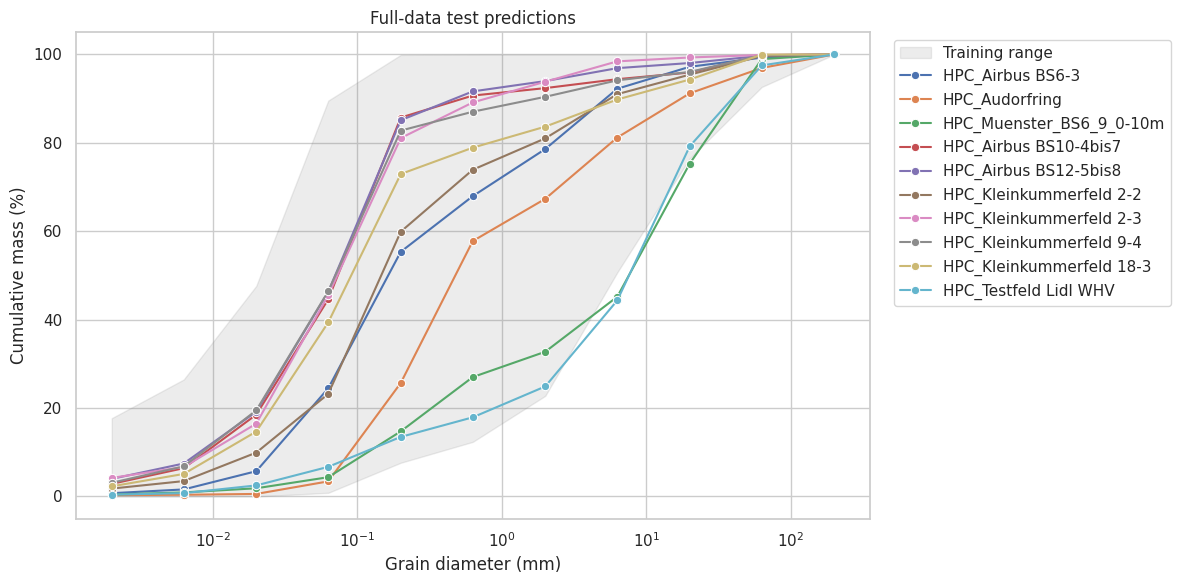

In [24]:
submission = sample_submission.copy()

sample_features, sample_metadata = feature_rows["sample_mean_std"]
feature_lookup = dict(zip(sample_metadata["sample_id"], sample_features))
submission_ids = submission.iloc[:, 0].astype(str).tolist()
target_columns = submission.columns[1:].tolist()
diameters = np.array([float(column) for column in target_columns])

X_train_final = np.vstack([feature_lookup[sample_id] for sample_id in train_ids])
X_test_final = np.vstack([feature_lookup[sample_id] for sample_id in submission_ids])

def fit_full_target_model(mode, alpha=1):
    scaler = StandardScaler().fit(X_train_final)
    model = Ridge(alpha=alpha, solver="lsqr").fit(scaler.transform(X_train_final), encode_distribution(targets, mode, 0))
    return decode_distribution(model.predict(scaler.transform(X_test_final)), mode), scaler, model

test_sqrt, final_scaler, final_model = fit_full_target_model("sqrt_mass", alpha=1)
test_direct, _, _ = fit_full_target_model("direct", alpha=1)

def estimate_d50(curve):
    index = np.searchsorted(curve, 50)
    if index == 0:
        return diameters[0]
    if index == len(curve):
        return diameters[-1]
    y0, y1 = curve[index - 1], curve[index]
    fraction = 0 if y1 == y0 else (50 - y0) / (y1 - y0)
    return 10 ** (np.log10(diameters[index - 1]) + fraction * (np.log10(diameters[index]) - np.log10(diameters[index - 1])))

test_summary = pd.DataFrame({
    "sample_id": submission_ids,
    "D50_mm": [estimate_d50(curve) for curve in test_sqrt],
    "Clay_<0.002": test_sqrt[:, 0],
    "Silt_0.002–0.063": test_sqrt[:, 3] - test_sqrt[:, 0],
    "Sand_0.063–2": test_sqrt[:, 6] - test_sqrt[:, 3],
    "Gravel_2–63": test_sqrt[:, 9] - test_sqrt[:, 6],
    "Cobbles_63–200": test_sqrt[:, 10] - test_sqrt[:, 9],
    "Direct–sqrt_disagreement": emd_per_sample(test_direct, test_sqrt)
})
display(test_summary.round(3))

print(f"Range: {test_sqrt.min():.3f} to {test_sqrt.max():.3f}")
print(f"Non-monotonic curves: {(np.diff(test_sqrt, axis=1) < -1e-8).any(axis=1).sum()}")
print(f"Curves not ending at 100: {(np.abs(test_sqrt[:, -1] - 100) > 1e-8).sum()}")

submission_sqrt = submission.copy()
submission_sqrt.loc[:, target_columns] = test_sqrt
submission_path = "/kaggle/working/submission_sqrt_mass.csv"
submission_sqrt.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")

plot_data = submission_sqrt.melt(id_vars=submission.columns[0], var_name="diameter_mm", value_name="cumulative_mass")
plot_data["diameter_mm"] = plot_data["diameter_mm"].astype(float)
plt.figure(figsize=(12, 6))
plt.fill_between(diameters, targets.min(0), targets.max(0), color="gray", alpha=.15, label="Training range")
sns.lineplot(data=plot_data, x="diameter_mm", y="cumulative_mass", hue=submission.columns[0], marker="o")
plt.xscale("log")
plt.xlabel("Grain diameter (mm)")
plt.ylabel("Cumulative mass (%)")
plt.title("Full-data test predictions")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [25]:
test_sqrt = np.maximum.accumulate(np.clip(test_sqrt.astype(np.float64), 0, 100), axis=1)
test_sqrt[:, -1] = 100.0

submission_sqrt = sample_submission.copy()
submission_sqrt.loc[:, target_columns] = test_sqrt
submission_path = "/kaggle/working/submission_sqrt_mass.csv"
submission_sqrt.to_csv(submission_path, index=False, float_format="%.6f")

print(f"Shape: {submission_sqrt.shape} | Missing values: {submission_sqrt.isna().sum().sum()}")
print(f"Non-monotonic curves: {(np.diff(test_sqrt, axis=1) < 0).any(axis=1).sum()}")
print(f"Curves ending exactly at 100: {(test_sqrt[:, -1] == 100).sum()}/{len(test_sqrt)}")
print(f"Saved to: {submission_path}")
display(submission_sqrt)

Shape: (10, 12) | Missing values: 0
Non-monotonic curves: 0
Curves ending exactly at 100: 10/10
Saved to: /kaggle/working/submission_sqrt_mass.csv


,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,HPC_Airbus BS6-3,0.736728,1.588395,5.712670,24.466507,55.348282,67.934952,78.597717,92.234444,97.209396,99.274101,100.0
1,HPC_Audorfring,0.287941,0.380753,0.569176,3.410469,25.670650,57.777607,67.335739,81.194214,91.204376,96.942070,100.0
2,HPC_Muenster_BS6_9_0-10m,0.436115,0.915897,1.847580,4.352619,14.722849,27.004711,32.736832,45.177742,75.314095,98.938751,100.0
3,HPC_Airbus BS10-4bis7,2.844185,6.401938,18.509001,44.605068,85.721710,90.692612,92.381264,94.400223,95.913239,99.800797,100.0
4,HPC_Airbus BS12-5bis8,3.973561,7.452814,19.184803,46.318939,85.122467,91.635132,93.968781,96.897346,98.059616,99.692062,100.0
5,HPC_Kleinkummerfeld 2-2,1.778074,3.473985,9.912971,23.198814,59.896870,73.913574,81.013519,91.006348,95.429932,99.660995,100.0
6,HPC_Kleinkummerfeld 2-3,4.188890,6.669463,16.465361,45.528976,81.077026,89.138168,93.830254,98.431892,99.314064,99.879265,100.0
7,HPC_Kleinkummerfeld 9-4,3.092092,6.807206,19.475368,46.419552,82.766022,87.039917,90.413223,94.139221,96.043312,99.828392,100.0
8,HPC_Kleinkummerfeld 18-3,2.285142,5.094342,14.678033,39.385529,72.943146,78.903473,83.664131,89.805351,94.324951,99.971031,100.0
9,HPC_Testfeld Lidl WHV,0.404449,0.751085,2.494762,6.698390,13.466815,17.900909,24.887978,44.344177,79.233856,97.514664,100.0
